---
---

### <center>NTPC :: Power Prediction</center>

---

In [1]:
!pip install -q openpyxl nbformat pandas matplotlib plotly scikit-learn xgboost lightgbm catboost torch shap

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle as pkl
import torch
import shap

from math import sqrt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import plotly.graph_objects as go

c:\AIonOS--KVNAditya\AIonOS\sciencia\ntpc\frontend\ntpc_dashboard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

In [3]:
xldf__01 = pd.read_excel("datum/Plant_coal_power_stock_set 1.xlsx", sheet_name=None)
xldf__01_01 = xldf__01[list(xldf__01.keys())[0]]

In [4]:
xldf__01_01.drop(xldf__01_01.columns.difference(["Date", "Barh(Power GW)", "Dadri Thermal(Power GW)", "Kudgi(Power GW)"], sort=False), axis=1, inplace=True)
xldf__01_01.set_index("Date", inplace=True)

In [5]:
xldf__01_01__barh = xldf__01_01["Barh(Power GW)"].to_frame().rename(columns={"Barh(Power GW)" : "powerGW"})
xldf__01_01__dadri = xldf__01_01["Dadri Thermal(Power GW)"].to_frame().rename(columns={"Dadri Thermal(Power GW)" : "powerGW"})
xldf__01_01__kudgi = xldf__01_01["Kudgi(Power GW)"].to_frame().rename(columns={"Kudgi(Power GW)" : "powerGW"})

---

In [6]:
for itr in range(0, 7): xldf__01_01__barh[f"lg{itr+1}"] = xldf__01_01__barh["powerGW"].shift(itr+1).round(4)
xldf__01_01__barh['lgmn7'] = xldf__01_01__barh.iloc[:, 0:6].mean(axis=1)
xldf__01_01__barh['lgvr7'] = xldf__01_01__barh.iloc[:, 0:6].var(axis=1)
xldf__01_01__barh['lgsd7'] = xldf__01_01__barh.iloc[:, 0:6].std(axis=1)
xldf__01_01__barh['nyweek'] = xldf__01_01__barh.index.isocalendar().week
xldf__01_01__barh['nmweek'] = xldf__01_01__barh.index.month
xldf__01_01__barh['ndweek'] = xldf__01_01__barh.index.dayofweek
xldf__01_01__barh.dropna(inplace=True)
xldf__01_01__barh = xldf__01_01__barh[xldf__01_01__barh.columns.to_list()[1:xldf__01_01__barh.shape[-1]]+[xldf__01_01__barh.columns.to_list()[0]]]

for itr in range(0, 7): xldf__01_01__dadri[f"lg{itr+1}"] = xldf__01_01__dadri["powerGW"].shift(itr+1).round(4)
xldf__01_01__dadri['lgmn7'] = xldf__01_01__dadri.iloc[:, 0:6].mean(axis=1)
xldf__01_01__dadri['lgvr7'] = xldf__01_01__dadri.iloc[:, 0:6].var(axis=1)
xldf__01_01__dadri['lgsd7'] = xldf__01_01__dadri.iloc[:, 0:6].std(axis=1)
xldf__01_01__dadri['ndweek'] = xldf__01_01__dadri.index.dayofweek
xldf__01_01__dadri['nmweek'] = xldf__01_01__dadri.index.month
xldf__01_01__dadri['nyweek'] = xldf__01_01__dadri.index.isocalendar().week
xldf__01_01__dadri.dropna(inplace=True)
xldf__01_01__dadri = xldf__01_01__dadri[xldf__01_01__dadri.columns.to_list()[1:xldf__01_01__dadri.shape[-1]]+[xldf__01_01__dadri.columns.to_list()[0]]]

for itr in range(0, 7): xldf__01_01__kudgi[f"lg{itr+1}"] = xldf__01_01__kudgi["powerGW"].shift(itr+1).round(4)
xldf__01_01__kudgi['lgmn7'] = xldf__01_01__kudgi.iloc[:, 0:6].mean(axis=1)
xldf__01_01__kudgi['lgvr7'] = xldf__01_01__kudgi.iloc[:, 0:6].var(axis=1)
xldf__01_01__kudgi['lgsd7'] = xldf__01_01__kudgi.iloc[:, 0:6].std(axis=1)
xldf__01_01__kudgi['ndweek'] = xldf__01_01__kudgi.index.dayofweek
xldf__01_01__kudgi['nmweek'] = xldf__01_01__kudgi.index.month
xldf__01_01__kudgi['nyweek'] = xldf__01_01__kudgi.index.isocalendar().week
xldf__01_01__kudgi.dropna(inplace=True)
xldf__01_01__kudgi = xldf__01_01__kudgi[xldf__01_01__kudgi.columns.to_list()[1:xldf__01_01__kudgi.shape[-1]]+[xldf__01_01__kudgi.columns.to_list()[0]]]

---

In [7]:
xldf__01_01__barh__11 = xldf__01_01__barh[:-201] ## train-test
xldf__01_01__barh__00 = xldf__01_01__barh[-201:] ## prediction/forecasting

xldf__01_01__dadri__11 = xldf__01_01__dadri[:-251]
xldf__01_01__dadri__00 = xldf__01_01__dadri[-251:]

xldf__01_01__kudgi__11 = xldf__01_01__kudgi[:-335]
xldf__01_01__kudgi__00 = xldf__01_01__kudgi[-335:]

xldf__01_01__barh__11.dropna(inplace=True)
xldf__01_01__barh__00.dropna(inplace=True)

xldf__01_01__dadri__11.dropna(inplace=True)
xldf__01_01__dadri__00.dropna(inplace=True)

xldf__01_01__kudgi__11.dropna(inplace=True)
xldf__01_01__kudgi__00.dropna(inplace=True)

C:\Users\Aditya.Kothapalli\AppData\Local\Temp\ipykernel_34424\2410156907.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xldf__01_01__barh__11.dropna(inplace=True)
C:\Users\Aditya.Kothapalli\AppData\Local\Temp\ipykernel_34424\2410156907.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xldf__01_01__barh__00.dropna(inplace=True)
C:\Users\Aditya.Kothapalli\AppData\Local\Temp\ipykernel_34424\2410156907.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

In [8]:
xldf__01_01__barh__train_x, xldf__01_01__barh__test_x = xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][:-201], xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][-201:]
xldf__01_01__barh__train_y, xldf__01_01__barh__test_y = xldf__01_01__barh__11[["powerGW"]][:-201], xldf__01_01__barh__11[["powerGW"]][-201:]

xldf__01_01__dadri__train_x, xldf__01_01__dadri__test_x = xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][:-251], xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][-251:]
xldf__01_01__dadri__train_y, xldf__01_01__dadri__test_y = xldf__01_01__dadri__11[["powerGW"]][:-251], xldf__01_01__dadri__11[["powerGW"]][-251:]

xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__test_x = xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][:-335], xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][-335:]
xldf__01_01__kudgi__train_y, xldf__01_01__kudgi__test_y = xldf__01_01__kudgi__11[["powerGW"]][:-335], xldf__01_01__kudgi__11[["powerGW"]][-335:]

In [9]:
xldf__01_01__barh__x = xldf__01_01__barh__00[xldf__01_01__barh__00.columns.difference(["powerGW"], sort=False)]
xldf__01_01__barh__y = xldf__01_01__barh__00[["powerGW"]]

xldf__01_01__dadri__x = xldf__01_01__dadri__00[xldf__01_01__dadri__00.columns.difference(["powerGW"], sort=False)]
xldf__01_01__dadri__y = xldf__01_01__dadri__00[["powerGW"]]

xldf__01_01__kudgi__x = xldf__01_01__kudgi__00[xldf__01_01__kudgi__00.columns.difference(["powerGW"], sort=False)]
xldf__01_01__kudgi__y = xldf__01_01__kudgi__00[["powerGW"]]

---

In [10]:
model_barh__xgboost = XGBRegressor(n_estimators=201, learning_rate=0.08, max_depth=7, random_state=0, verbosity=0)
model_barh__xgboost.fit(xldf__01_01__barh__train_x, xldf__01_01__barh__train_y)
model_barh__xgboost_predict = model_barh__xgboost.predict(xldf__01_01__barh__test_x)

model_dadri__xgboost = XGBRegressor(n_estimators=201, learning_rate=0.08, max_depth=7, random_state=0, verbosity=0)
model_dadri__xgboost.fit(xldf__01_01__dadri__train_x, xldf__01_01__dadri__train_y)
model_dadri__xgboost_predict = model_dadri__xgboost.predict(xldf__01_01__dadri__test_x)

model_kudgi__xgboost = XGBRegressor(n_estimators=201, learning_rate=0.08, max_depth=7, random_state=0, verbosity=0)
model_kudgi__xgboost.fit(xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__train_y)
model_kudgi__xgboost_predict = model_kudgi__xgboost.predict(xldf__01_01__kudgi__test_x)

In [11]:
model_barh__lightgbm = LGBMRegressor(iterations=201, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_barh__lightgbm.fit(xldf__01_01__barh__train_x, xldf__01_01__barh__train_y, eval_set=(xldf__01_01__barh__test_x, xldf__01_01__barh__test_y))
model_barh__lightgbm_predict = model_barh__lightgbm.predict(xldf__01_01__barh__test_x)

model_dadri__lightgbm = LGBMRegressor(iterations=251, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_dadri__lightgbm.fit(xldf__01_01__dadri__train_x, xldf__01_01__dadri__train_y, eval_set=(xldf__01_01__dadri__test_x, xldf__01_01__dadri__test_y))
model_dadri__lightgbm_predict = model_dadri__lightgbm.predict(xldf__01_01__dadri__test_x)

model_kudgi__lightgbm = LGBMRegressor(iterations=335, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_kudgi__lightgbm.fit(xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__train_y, eval_set=(xldf__01_01__kudgi__test_x, xldf__01_01__kudgi__test_y))
model_kudgi__lightgbm_predict = model_kudgi__lightgbm.predict(xldf__01_01__kudgi__test_x)

In [12]:
model_barh__catboost = CatBoostRegressor(iterations=201,learning_rate=0.08,depth=7,loss_function="RMSE",random_seed=0,verbose=False)
model_barh__catboost.fit(xldf__01_01__barh__train_x, xldf__01_01__barh__train_y, eval_set=(xldf__01_01__barh__test_x, xldf__01_01__barh__test_y), use_best_model=True)
model_barh__catboost_predict = model_barh__catboost.predict(xldf__01_01__barh__test_x)

model_dadri__catboost = CatBoostRegressor(iterations=251,learning_rate=0.08,depth=7,loss_function="RMSE",random_seed=0,verbose=False)
model_dadri__catboost.fit(xldf__01_01__dadri__train_x, xldf__01_01__dadri__train_y, eval_set=(xldf__01_01__dadri__test_x, xldf__01_01__dadri__test_y), use_best_model=True)
model_dadri__catboost_predict = model_dadri__catboost.predict(xldf__01_01__dadri__test_x)

model_kudgi__catboost = CatBoostRegressor(iterations=335,learning_rate=0.08,depth=7,loss_function="RMSE",random_seed=0,verbose=False)
model_kudgi__catboost.fit(xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__train_y, eval_set=(xldf__01_01__kudgi__test_x, xldf__01_01__kudgi__test_y), use_best_model=True)
model_kudgi__catboost_predict = np.round(model_kudgi__catboost.predict(xldf__01_01__kudgi__test_x), 4)

---

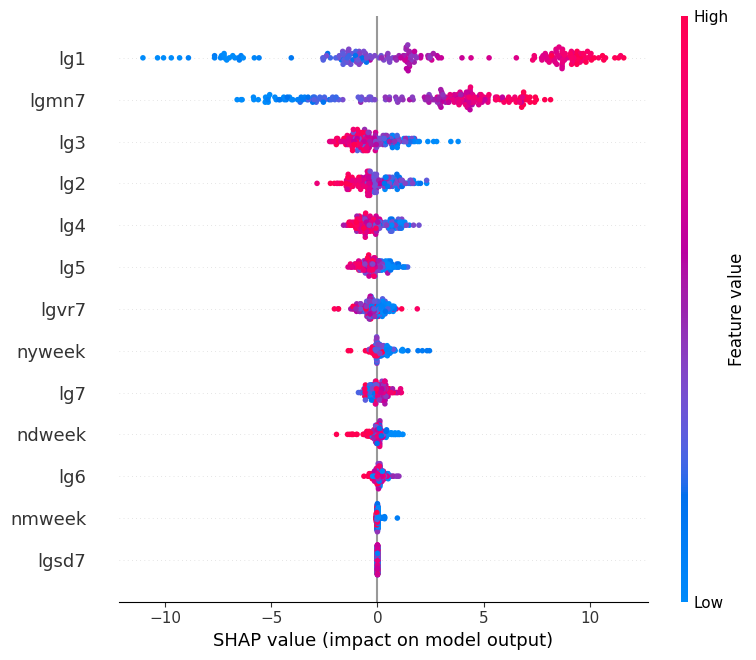

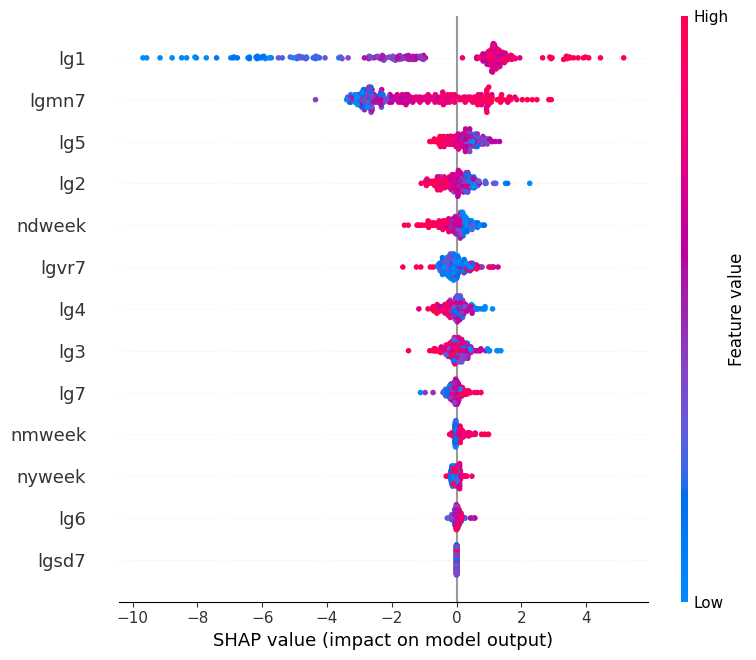

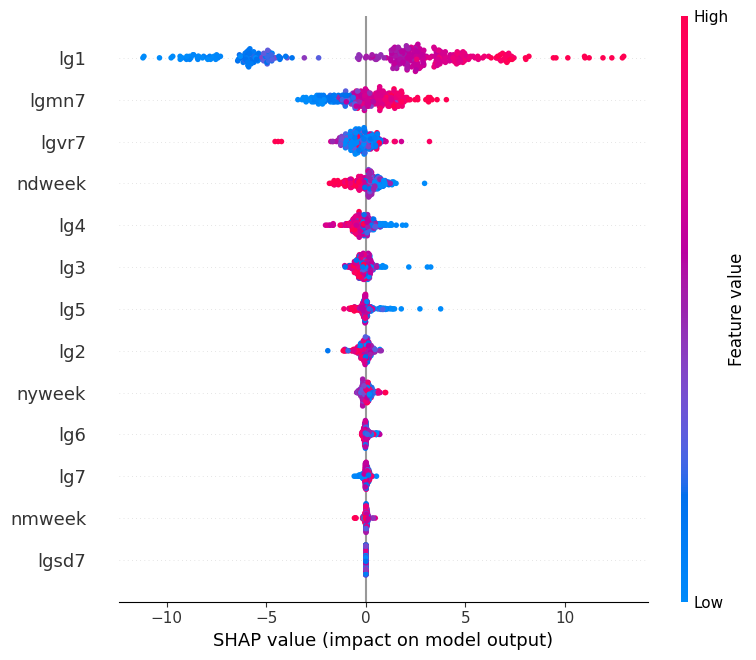

In [13]:
explainer = shap.TreeExplainer(model_barh__xgboost)
shap_values = explainer.shap_values(xldf__01_01__barh__test_x)
shap.summary_plot(shap_values, xldf__01_01__barh__test_x, feature_names=xldf__01_01__barh__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_dadri__xgboost)
shap_values = explainer.shap_values(xldf__01_01__dadri__test_x)
shap.summary_plot(shap_values, xldf__01_01__dadri__test_x, feature_names=xldf__01_01__dadri__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_kudgi__xgboost)
shap_values = explainer.shap_values(xldf__01_01__kudgi__test_x)
shap.summary_plot(shap_values, xldf__01_01__kudgi__test_x, feature_names=xldf__01_01__kudgi__test_x.columns.to_list())

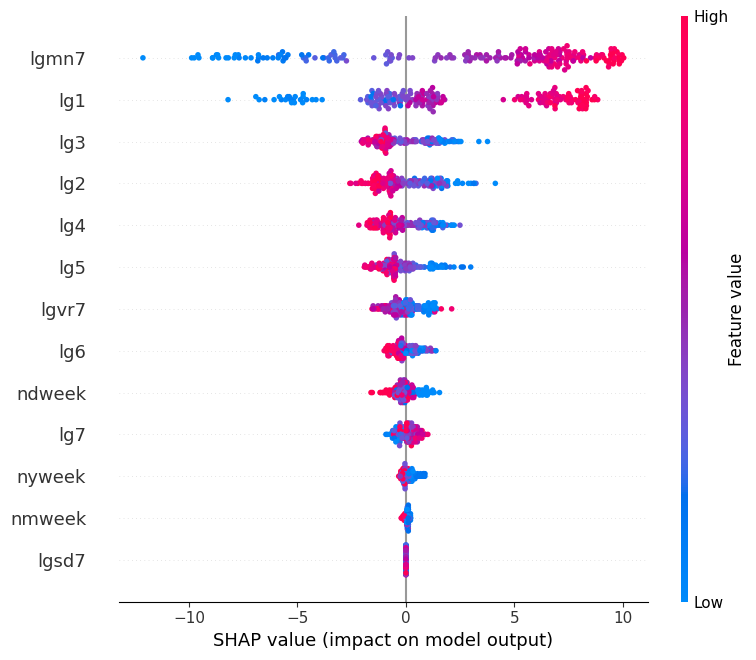

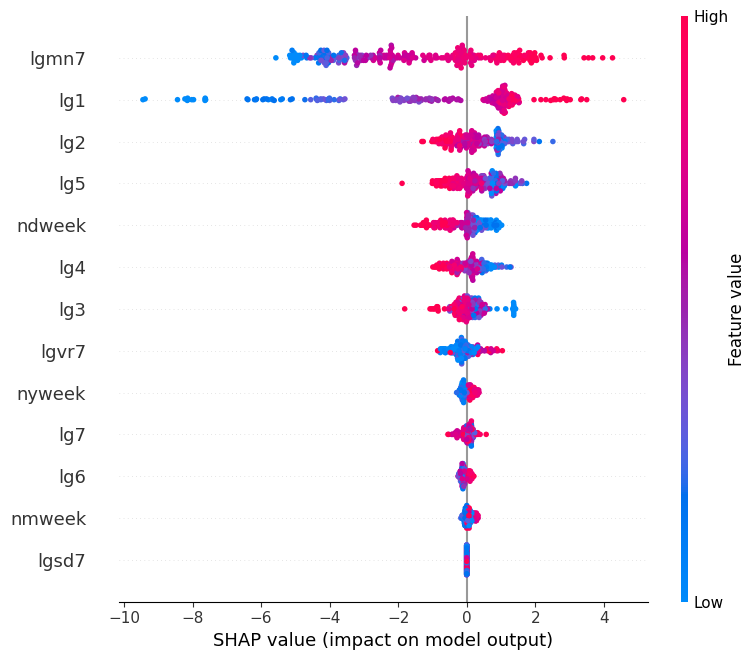

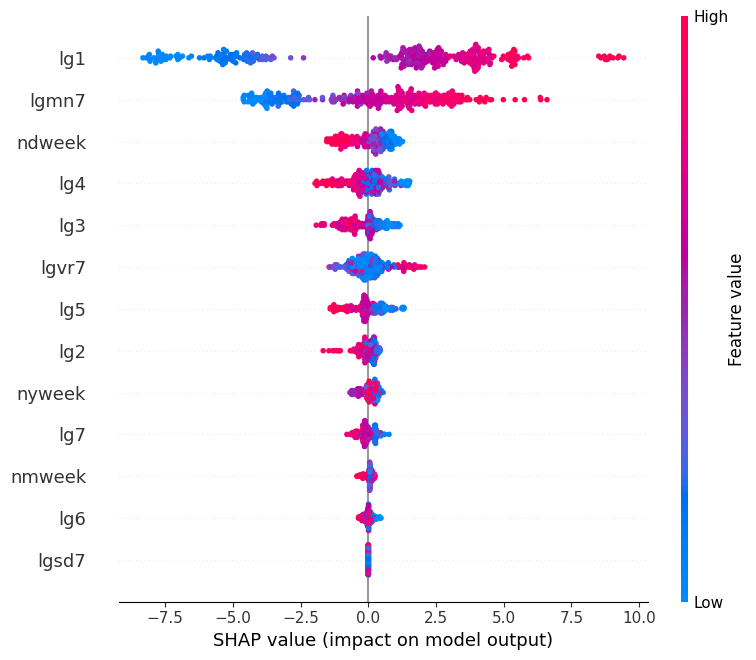

In [14]:
explainer = shap.TreeExplainer(model_barh__lightgbm)
shap_values = explainer.shap_values(xldf__01_01__barh__test_x)
shap.summary_plot(shap_values, xldf__01_01__barh__test_x, feature_names=xldf__01_01__barh__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_dadri__lightgbm)
shap_values = explainer.shap_values(xldf__01_01__dadri__test_x)
shap.summary_plot(shap_values, xldf__01_01__dadri__test_x, feature_names=xldf__01_01__dadri__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_kudgi__lightgbm)
shap_values = explainer.shap_values(xldf__01_01__kudgi__test_x)
shap.summary_plot(shap_values, xldf__01_01__kudgi__test_x, feature_names=xldf__01_01__kudgi__test_x.columns.to_list())

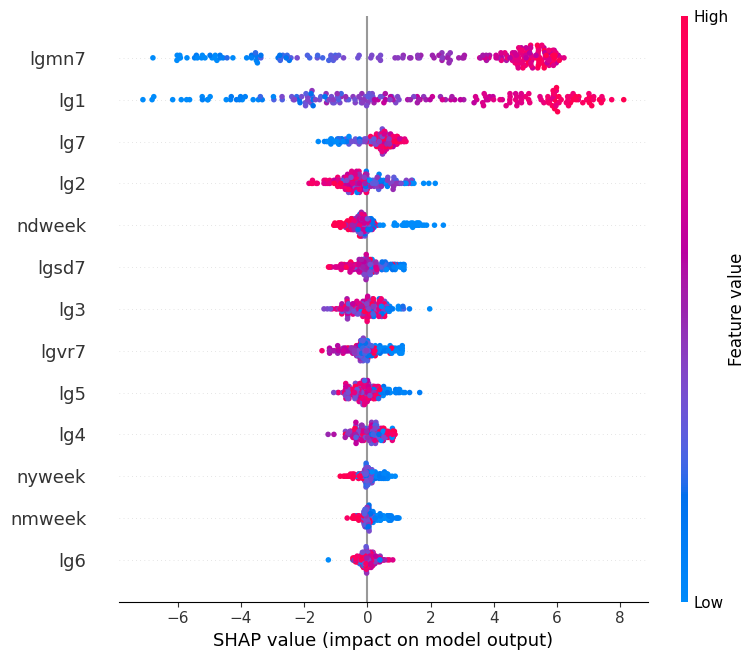

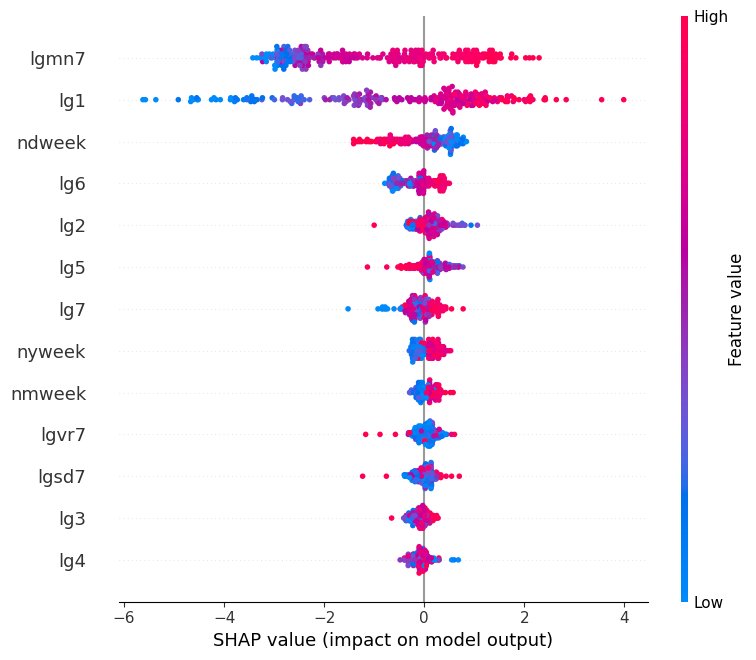

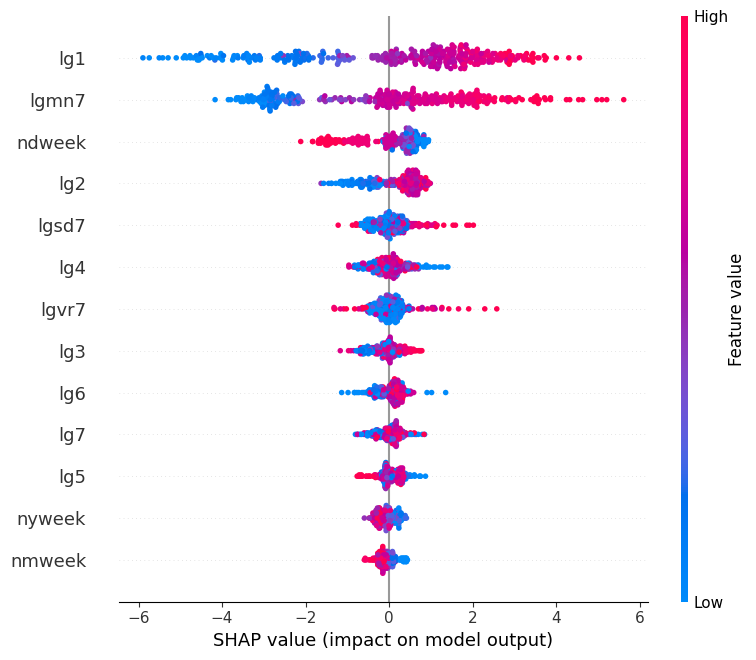

In [15]:
explainer = shap.TreeExplainer(model_barh__catboost)
shap_values = explainer.shap_values(xldf__01_01__barh__test_x)
shap.summary_plot(shap_values, xldf__01_01__barh__test_x, feature_names=xldf__01_01__barh__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_dadri__catboost)
shap_values = explainer.shap_values(xldf__01_01__dadri__test_x)
shap.summary_plot(shap_values, xldf__01_01__dadri__test_x, feature_names=xldf__01_01__dadri__test_x.columns.to_list())

explainer = shap.TreeExplainer(model_kudgi__catboost)
shap_values = explainer.shap_values(xldf__01_01__kudgi__test_x)
shap.summary_plot(shap_values, xldf__01_01__kudgi__test_x, feature_names=xldf__01_01__kudgi__test_x.columns.to_list())

---

Barh


metrics
XGboost RMSE: 4.792699133169022
XGboost MAPE: 8.277278393507004
LightGBM RMSE: 4.369016369157512
LightGBM MAPE: 7.584202309984089
CatBoost RMSE: 4.721261482558918
CatBoost MAPE: 8.897385737425248

plot


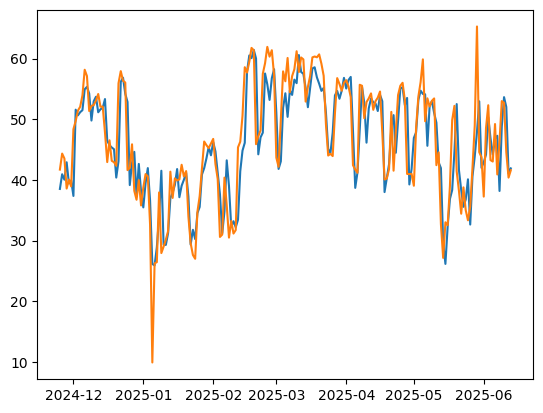

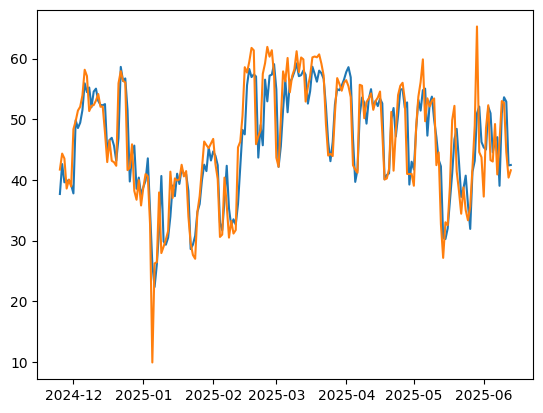

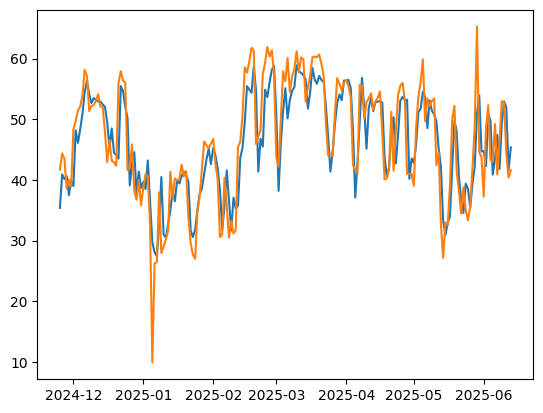

In [16]:
print("Barh")
print()
print()
print("metrics")
print("XGboost RMSE:", sqrt(mean_squared_error(xldf__01_01__barh__test_y, model_barh__xgboost_predict)))
print("XGboost MAPE:", mean_absolute_percentage_error(xldf__01_01__barh__test_y, model_barh__xgboost_predict)*100)
print("LightGBM RMSE:", sqrt(mean_squared_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict)))
print("LightGBM MAPE:", mean_absolute_percentage_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict)*100)
print("CatBoost RMSE:", sqrt(mean_squared_error(xldf__01_01__barh__test_y, model_barh__catboost_predict)))
print("CatBoost MAPE:", mean_absolute_percentage_error(xldf__01_01__barh__test_y, model_barh__catboost_predict)*100)
print()
print("plot")
plt.plot(xldf__01_01__barh__test_x.index, model_barh__xgboost_predict)
plt.plot(xldf__01_01__barh__test_x.index, xldf__01_01__barh__test_y)
plt.show()
plt.plot(xldf__01_01__barh__test_x.index, model_barh__lightgbm_predict)
plt.plot(xldf__01_01__barh__test_x.index, xldf__01_01__barh__test_y)
plt.show()
plt.plot(xldf__01_01__barh__test_x.index, model_barh__catboost_predict)
plt.plot(xldf__01_01__barh__test_x.index, xldf__01_01__barh__test_y)
plt.show()

Dadri


metrics
XGboost RMSE: 2.4936129998456593
XGboost MAPE: 7.503538578748703
LightGBM RMSE: 2.176959859689861
LightGBM MAPE: 6.7683595129405845
CatBoost RMSE: 2.37774489051782
CatBoost MAPE: 7.489302529633977

plot


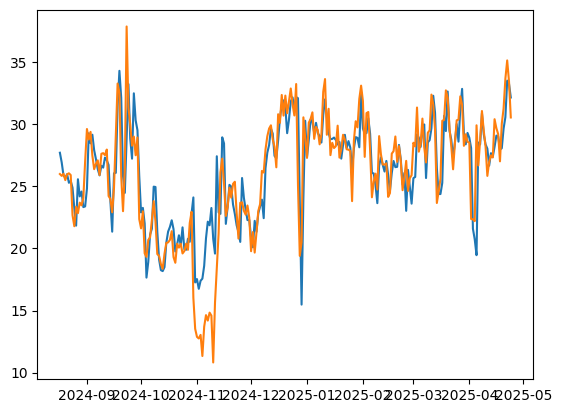

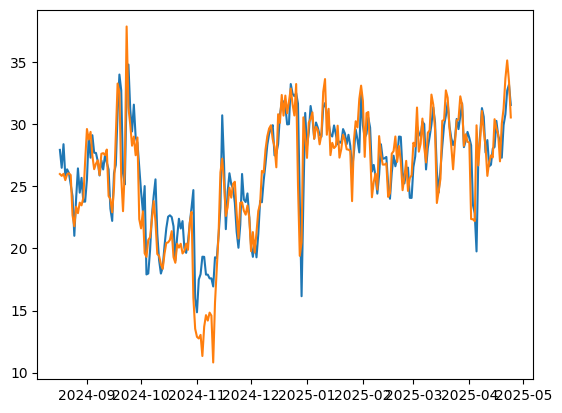

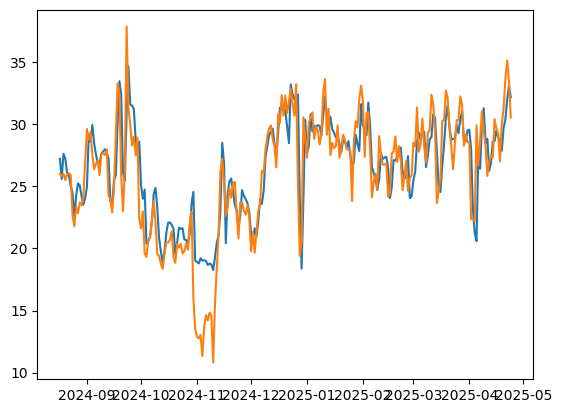

In [17]:
print("Dadri")
print()
print()
print("metrics")
print("XGboost RMSE:", sqrt(mean_squared_error(xldf__01_01__dadri__test_y, model_dadri__xgboost_predict)))
print("XGboost MAPE:", mean_absolute_percentage_error(xldf__01_01__dadri__test_y, model_dadri__xgboost_predict)*100)
print("LightGBM RMSE:", sqrt(mean_squared_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict)))
print("LightGBM MAPE:", mean_absolute_percentage_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict)*100)
print("CatBoost RMSE:", sqrt(mean_squared_error(xldf__01_01__dadri__test_y, model_dadri__catboost_predict)))
print("CatBoost MAPE:", mean_absolute_percentage_error(xldf__01_01__dadri__test_y, model_dadri__catboost_predict)*100)
print()
print("plot")
plt.plot(xldf__01_01__dadri__test_x.index, model_dadri__xgboost_predict)
plt.plot(xldf__01_01__dadri__test_x.index, xldf__01_01__dadri__test_y)
plt.show()
plt.plot(xldf__01_01__dadri__test_x.index, model_dadri__lightgbm_predict)
plt.plot(xldf__01_01__dadri__test_x.index, xldf__01_01__dadri__test_y)
plt.show()
plt.plot(xldf__01_01__dadri__test_x.index, model_dadri__catboost_predict)
plt.plot(xldf__01_01__dadri__test_x.index, xldf__01_01__dadri__test_y)
plt.show()

Kudgi


metrics
XGboost RMSE: 3.5044048384118485
XGboost MAPE: 9.027241915464401
LightGBM RMSE: 3.3446323489747964
LightGBM MAPE: 9.130392803012002
CatBoost RMSE: 3.487161759826181
CatBoost MAPE: 9.359174948871013

plot


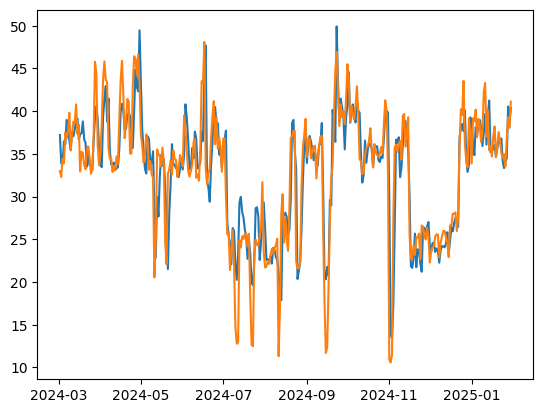

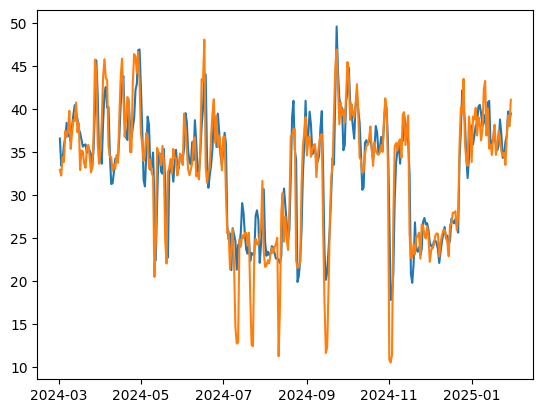

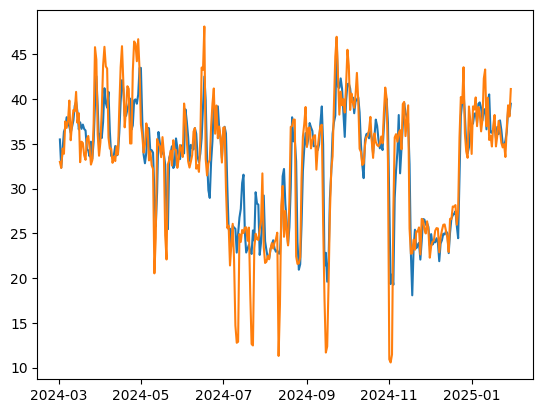

In [18]:
print("Kudgi")
print()
print()
print("metrics")
print("XGboost RMSE:", sqrt(mean_squared_error(xldf__01_01__kudgi__test_y, model_kudgi__xgboost_predict)))
print("XGboost MAPE:", mean_absolute_percentage_error(xldf__01_01__kudgi__test_y, model_kudgi__xgboost_predict)*100)
print("LightGBM RMSE:", sqrt(mean_squared_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict)))
print("LightGBM MAPE:", mean_absolute_percentage_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict)*100)
print("CatBoost RMSE:", sqrt(mean_squared_error(xldf__01_01__kudgi__test_y, model_kudgi__catboost_predict)))
print("CatBoost MAPE:", mean_absolute_percentage_error(xldf__01_01__kudgi__test_y, model_kudgi__catboost_predict)*100)
print()
print("plot")
plt.plot(xldf__01_01__kudgi__test_x.index, model_kudgi__xgboost_predict)
plt.plot(xldf__01_01__kudgi__test_x.index, xldf__01_01__kudgi__test_y)
plt.show()
plt.plot(xldf__01_01__kudgi__test_x.index, model_kudgi__lightgbm_predict)
plt.plot(xldf__01_01__kudgi__test_x.index, xldf__01_01__kudgi__test_y)
plt.show()
plt.plot(xldf__01_01__kudgi__test_x.index, model_kudgi__catboost_predict)
plt.plot(xldf__01_01__kudgi__test_x.index, xldf__01_01__kudgi__test_y)
plt.show()

---

In [19]:
# class model_barh__torch_LSTM(nn.Module):
#     torch.manual_seed(201)
#     torch.cuda.manual_seed_all(201)
#     np.random.seed(201)
      
#     def __init__(self, io):
#         super().__init__()
#         self.lstm = nn.LSTM(io, 201, batch_first=True)
#         self.dnn = nn.Linear(201, 1)
#     def forward(self, x):
#         _, (n, _) = self.lstm(x)
#         return self.dnn(n[-1]) 
# class model_dadri__torch_LSTM(nn.Module):
#     torch.manual_seed(251)
#     torch.cuda.manual_seed_all(251)
#     np.random.seed(251)

#     def __init__(self, io):
#         super().__init__()
#         self.lstm = nn.LSTM(io, 251, batch_first=True)
#         self.dnn = nn.Linear(251, 1)
#     def forward(self, x):
#         _, (n, _) = self.lstm(x)
#         return self.dnn(n[-1])
# class model_kudgi__torch_LSTM(nn.Module):
#     torch.manual_seed(335)
#     torch.cuda.manual_seed_all(335)
#     np.random.seed(335)

#     def __init__(self, io):
#         super().__init__()
#         self.lstm = nn.LSTM(io, 335, batch_first=True)
#         self.dnn = nn.Linear(335, 1)
#     def forward(self, x):
#         _, (n, _) = self.lstm(x)
#         return self.dnn(n[-1])

# xldf__01_01__scaler = StandardScaler()

# xldf__01_01__barh__train_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__barh__train_x).reshape(xldf__01_01__barh__train_x.shape[0], 1, xldf__01_01__barh__train_x.shape[1])
# xldf__01_01__barh__test_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__barh__test_x).reshape(xldf__01_01__barh__test_x.shape[0], 1, xldf__01_01__barh__test_x.shape[1])
# xldf__01_01__dadri__train_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__dadri__train_x).reshape(xldf__01_01__dadri__train_x.shape[0], 1, xldf__01_01__dadri__train_x.shape[1])
# xldf__01_01__dadri__test_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__dadri__test_x).reshape(xldf__01_01__dadri__test_x.shape[0], 1, xldf__01_01__dadri__test_x.shape[1])
# xldf__01_01__kudgi__train_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__kudgi__train_x).reshape(xldf__01_01__kudgi__train_x.shape[0], 1, xldf__01_01__kudgi__train_x.shape[1])
# xldf__01_01__kudgi__test_x__scaled = xldf__01_01__scaler.fit_transform(xldf__01_01__kudgi__test_x).reshape(xldf__01_01__kudgi__test_x.shape[0], 1, xldf__01_01__kudgi__test_x.shape[1])

# xldf__01_01__barh__train_x__scaled_tensor = torch.tensor(xldf__01_01__barh__train_x__scaled, dtype=torch.float)
# xldf__01_01__barh__test_x__scaled_tensor = torch.tensor(xldf__01_01__barh__test_x__scaled, dtype=torch.float)
# xldf__01_01__barh__train_y__tensor = torch.tensor(xldf__01_01__barh__train_y.values, dtype=torch.float).view(-1,1)
# xldf__01_01__barh__test_y__tensor = torch.tensor(xldf__01_01__barh__test_y.values, dtype=torch.float).view(-1,1)
# xldf__01_01__dadri__train_x__scaled_tensor = torch.tensor(xldf__01_01__dadri__train_x__scaled, dtype=torch.float)
# xldf__01_01__dadri__test_x__scaled_tensor = torch.tensor(xldf__01_01__dadri__test_x__scaled, dtype=torch.float)
# xldf__01_01__dadri__train_y__tensor = torch.tensor(xldf__01_01__dadri__train_y.values, dtype=torch.float).view(-1,1)
# xldf__01_01__dadri__test_y__tensor = torch.tensor(xldf__01_01__dadri__test_y.values, dtype=torch.float).view(-1,1)
# xldf__01_01__kudgi__train_x__scaled_tensor = torch.tensor(xldf__01_01__kudgi__train_x__scaled, dtype=torch.float)
# xldf__01_01__kudgi__test_x__scaled_tensor = torch.tensor(xldf__01_01__kudgi__test_x__scaled, dtype=torch.float)
# xldf__01_01__kudgi__train_y__tensor = torch.tensor(xldf__01_01__kudgi__train_y.values, dtype=torch.float).view(-1,1)
# xldf__01_01__kudgi__test_y__tensor = torch.tensor(xldf__01_01__kudgi__test_y.values, dtype=torch.float).view(-1,1)

# print("Barh")
# print()
# print()
# model_barh__LSTM = model_barh__torch_LSTM(xldf__01_01__barh__train_x__scaled_tensor.shape[2])
# model_barh__LSTM_lossfunc = nn.MSELoss()
# model_barh__LSTM_optm = torch.optim.Adam(model_barh__LSTM.parameters(), lr=0.8)
# for itr in range(201):
#     model_barh__LSTM_train = model_barh__LSTM(xldf__01_01__barh__train_x__scaled_tensor)
#     model_barh__LSTM_train_loss = model_barh__LSTM_lossfunc(model_barh__LSTM_train, xldf__01_01__barh__train_y__tensor)

#     model_barh__LSTM_optm.zero_grad()
#     model_barh__LSTM_train_loss.backward()
#     model_barh__LSTM_optm.step()

#     with torch.no_grad():
#         model_barh__LSTM_test = model_barh__LSTM(xldf__01_01__barh__test_x__scaled_tensor)
#         model_barh__LSTM_test_loss = model_barh__LSTM_lossfunc(model_barh__LSTM_test, xldf__01_01__barh__test_y__tensor).item()
    
#     if(): pass
#     elif(201%(itr+1) == 0):
#         print(f"({itr+1}|201) || train_loss : {model_barh__LSTM_train_loss.item()} | test_loss : {model_barh__LSTM_test_loss}")

# print("Dadri")
# print()
# print()
# model_dadri__LSTM = model_dadri__torch_LSTM(xldf__01_01__dadri__train_x__scaled_tensor.shape[2])
# model_dadri__LSTM_lossfunc = nn.MSELoss()
# model_dadri__LSTM_optm = torch.optim.Adam(model_dadri__LSTM.parameters(), lr=0.8)
# for itr in range(251):
#     model_dadri__LSTM_train = model_dadri__LSTM(xldf__01_01__dadri__train_x__scaled_tensor)
#     model_dadri__LSTM_train_loss = model_dadri__LSTM_lossfunc(model_dadri__LSTM_train, xldf__01_01__dadri__train_y__tensor)

#     model_dadri__LSTM_optm.zero_grad()
#     model_dadri__LSTM_train_loss.backward()
#     model_dadri__LSTM_optm.step()

#     with torch.no_grad():
#         model_dadri__LSTM_test = model_dadri__LSTM(xldf__01_01__dadri__test_x__scaled_tensor)
#         model_dadri__LSTM_test_loss = model_dadri__LSTM_lossfunc(model_dadri__LSTM_test, xldf__01_01__dadri__test_y__tensor).item()
    
#     if(): pass
#     elif(251%(itr+1) == 0):
#         print(f"({itr+1}|251) || train_loss : {model_dadri__LSTM_train_loss.item()} | test_loss : {model_dadri__LSTM_test_loss}")

# print("Kudgi")
# print()
# print()
# model_kudgi__LSTM = model_kudgi__torch_LSTM(xldf__01_01__kudgi__train_x__scaled_tensor.shape[2])
# model_kudgi__LSTM_lossfunc = nn.MSELoss()
# model_kudgi__LSTM_optm = torch.optim.Adam(model_kudgi__LSTM.parameters(), lr=0.8)
# for itr in range(335):
#     model_kudgi__LSTM_train = model_kudgi__LSTM(xldf__01_01__kudgi__train_x__scaled_tensor)
#     model_kudgi__LSTM_train_loss = model_kudgi__LSTM_lossfunc(model_kudgi__LSTM_train, xldf__01_01__kudgi__train_y__tensor)

#     model_kudgi__LSTM_optm.zero_grad()
#     model_kudgi__LSTM_train_loss.backward()
#     model_kudgi__LSTM_optm.step()

#     with torch.no_grad():
#         model_kudgi__LSTM_test = model_kudgi__LSTM(xldf__01_01__kudgi__test_x__scaled_tensor)
#         model_kudgi__LSTM_test_loss = model_kudgi__LSTM_lossfunc(model_kudgi__LSTM_test, xldf__01_01__kudgi__test_y__tensor).item()
    
#     if(): pass
#     elif(335%(itr+1) == 0):
#         print(f"({itr+1}|335) || train_loss : {model_kudgi__LSTM_train_loss.item()} | test_loss : {model_kudgi__LSTM_test_loss}")

---

In [20]:
xldf__01_01__barh__train_x__y_n__metric_rmse__dct = {}
xldf__01_01__barh__train_x__y_n__metric_mape__dct = {}

for itr in range(0, 201):
    print(f"n_days = y{itr+1}")

    xldf__01_01__barh__train_x, xldf__01_01__barh__test_x = xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][0:-201], xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][-201:xldf__01_01__barh__11.shape[0]-itr]
    xldf__01_01__barh__train_y, xldf__01_01__barh__test_y = xldf__01_01__barh__11[["powerGW"]][itr:-(201-itr)], xldf__01_01__barh__11[["powerGW"]][-(201-itr):xldf__01_01__barh__11.shape[0]]

    model_barh__lightgbm = LGBMRegressor(iterations=201, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
    model_barh__lightgbm.fit(xldf__01_01__barh__train_x, xldf__01_01__barh__train_y, eval_set=(xldf__01_01__barh__test_x, xldf__01_01__barh__test_y))
    model_barh__lightgbm_predict__validation = model_barh__lightgbm.predict(xldf__01_01__barh__test_x)
    
    xldf__01_01__barh__train_x__y_n__metric_rmse__dct[itr] = sqrt(mean_squared_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict__validation))
    xldf__01_01__barh__train_x__y_n__metric_mape__dct[itr] = mean_absolute_percentage_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict__validation)*100

    print("metric_rmse:", xldf__01_01__barh__train_x__y_n__metric_rmse__dct[itr])
    print("metric_mape:", xldf__01_01__barh__train_x__y_n__metric_mape__dct[itr])

n_days = y1
metric_rmse: 4.369016369157512
metric_mape: 7.584202309984089
n_days = y2
metric_rmse: 7.0223319132710404
metric_mape: 13.584769886920009
n_days = y3
metric_rmse: 8.945898319963495
metric_mape: 17.532152200772895
n_days = y4
metric_rmse: 9.77959643867672
metric_mape: 18.954437998566785
n_days = y5
metric_rmse: 9.686681629421063
metric_mape: 18.577843485583205
n_days = y6
metric_rmse: 9.599638656457872
metric_mape: 18.424031804576078
n_days = y7
metric_rmse: 9.87212298039788
metric_mape: 18.671723123173813
n_days = y8
metric_rmse: 10.347800079274052
metric_mape: 19.15009680987716
n_days = y9
metric_rmse: 10.963455418926053
metric_mape: 20.652713457304113
n_days = y10
metric_rmse: 10.907169867575785
metric_mape: 20.50072159926226
n_days = y11
metric_rmse: 11.15658668471452
metric_mape: 20.792042084410316
n_days = y12
metric_rmse: 11.317302147186648
metric_mape: 21.299080931546357
n_days = y13
metric_rmse: 11.506787170188025
metric_mape: 21.630451194951554
n_days = y14
metric_

In [21]:
xldf__01_01__dadri__train_x__y_n__metric_rmse__dct = {}
xldf__01_01__dadri__train_x__y_n__metric_mape__dct = {}

for itr in range(0, 251):
    print(f"n_days = y{itr+1}")

    xldf__01_01__dadri__train_x, xldf__01_01__dadri__test_x = xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][0:-251], xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][-251:xldf__01_01__dadri__11.shape[0]-itr]
    xldf__01_01__dadri__train_y, xldf__01_01__dadri__test_y = xldf__01_01__dadri__11[["powerGW"]][itr:-(251-itr)], xldf__01_01__dadri__11[["powerGW"]][-(251-itr):xldf__01_01__dadri__11.shape[0]]

    model_dadri__lightgbm = LGBMRegressor(iterations=251, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
    model_dadri__lightgbm.fit(xldf__01_01__dadri__train_x, xldf__01_01__dadri__train_y, eval_set=(xldf__01_01__dadri__test_x, xldf__01_01__dadri__test_y))
    model_dadri__lightgbm_predict__validation = model_dadri__lightgbm.predict(xldf__01_01__dadri__test_x)
    
    xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[itr] = sqrt(mean_squared_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict__validation))
    xldf__01_01__dadri__train_x__y_n__metric_mape__dct[itr] = mean_absolute_percentage_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict__validation)*100

    print("metric_rmse:", xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[itr])
    print("metric_mape:", xldf__01_01__dadri__train_x__y_n__metric_mape__dct[itr])


n_days = y1
metric_rmse: 2.176959859689861
metric_mape: 6.7683595129405845
n_days = y2
metric_rmse: 3.9395229781903134
metric_mape: 13.023875004211607
n_days = y3
metric_rmse: 4.774944488609102
metric_mape: 16.224687500319344
n_days = y4
metric_rmse: 5.323376725662692
metric_mape: 18.063153112189433
n_days = y5
metric_rmse: 5.578963515419032
metric_mape: 18.92799557391912
n_days = y6
metric_rmse: 5.563185727241817
metric_mape: 19.00083114707551
n_days = y7
metric_rmse: 6.0118283422274175
metric_mape: 21.074024293483532
n_days = y8
metric_rmse: 5.8988296313571995
metric_mape: 20.75532557082987
n_days = y9
metric_rmse: 5.735001744772062
metric_mape: 19.861458176978957
n_days = y10
metric_rmse: 5.772013420660557
metric_mape: 20.14012948584363
n_days = y11
metric_rmse: 5.8371035829061455
metric_mape: 20.215153546443084
n_days = y12
metric_rmse: 5.774646099020001
metric_mape: 19.451664016319796
n_days = y13
metric_rmse: 6.012896877022056
metric_mape: 19.997583608407997
n_days = y14
metric_r

In [22]:
xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct = {}
xldf__01_01__kudgi__train_x__y_n__metric_mape__dct = {}

for itr in range(0, 335):
    print(f"n_days = y{itr+1}")

    xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__test_x = xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][0:-335], xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][-335:xldf__01_01__kudgi__11.shape[0]-itr]
    xldf__01_01__kudgi__train_y, xldf__01_01__kudgi__test_y = xldf__01_01__kudgi__11[["powerGW"]][itr:-(335-itr)], xldf__01_01__kudgi__11[["powerGW"]][-(335-itr):xldf__01_01__kudgi__11.shape[0]]

    model_kudgi__lightgbm = LGBMRegressor(iterations=335, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
    model_kudgi__lightgbm.fit(xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__train_y, eval_set=(xldf__01_01__kudgi__test_x, xldf__01_01__kudgi__test_y))
    model_kudgi__lightgbm_predict__validation = model_kudgi__lightgbm.predict(xldf__01_01__kudgi__test_x)
    
    xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[itr] = sqrt(mean_squared_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict__validation))
    xldf__01_01__kudgi__train_x__y_n__metric_mape__dct[itr] = mean_absolute_percentage_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict__validation)*100

    print("metric_rmse:", xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[itr])
    print("metric_mape:", xldf__01_01__kudgi__train_x__y_n__metric_mape__dct[itr])

n_days = y1
metric_rmse: 3.3446323489747964
metric_mape: 9.130392803012002
n_days = y2
metric_rmse: 5.08539872511007
metric_mape: 14.079922155597943
n_days = y3
metric_rmse: 6.043578233220948
metric_mape: 17.011174357875245
n_days = y4
metric_rmse: 6.375825355309595
metric_mape: 17.86131984576114
n_days = y5
metric_rmse: 6.686865861167896
metric_mape: 18.41691855392778
n_days = y6
metric_rmse: 6.627779326597276
metric_mape: 17.72503269049209
n_days = y7
metric_rmse: 6.96035064353535
metric_mape: 18.704004100691474
n_days = y8
metric_rmse: 7.377930241133326
metric_mape: 19.964998921572956
n_days = y9
metric_rmse: 7.40189058816344
metric_mape: 20.117231149516446
n_days = y10
metric_rmse: 7.446760837750518
metric_mape: 19.699293549327077
n_days = y11
metric_rmse: 7.234240115376465
metric_mape: 19.201282450728854
n_days = y12
metric_rmse: 7.2104514056436955
metric_mape: 19.19516409097301
n_days = y13
metric_rmse: 7.461524991287018
metric_mape: 19.81022166050601
n_days = y14
metric_rmse: 7.

In [23]:
# pd.concat([pd.DataFrame(xldf__01_01__barh__test_y.values, index=xldf__01_01__barh__train_x__y_n__metric_rmse__dct.keys(), columns=["powerGW"]), pd.DataFrame.from_dict(xldf__01_01__barh__train_x__y_n__metric_rmse__dct, orient="index", columns=["rmse"])], axis=1).head(60)


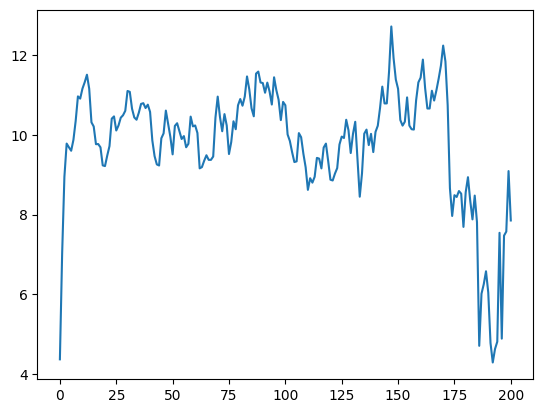

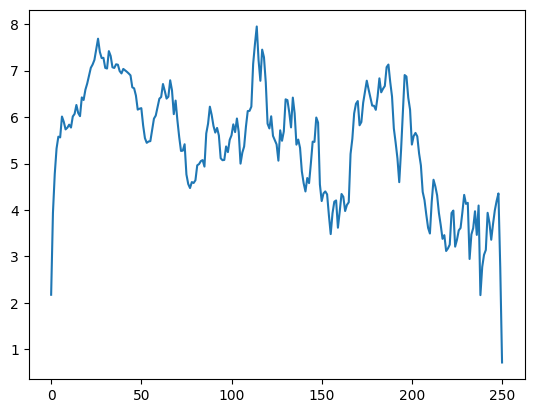

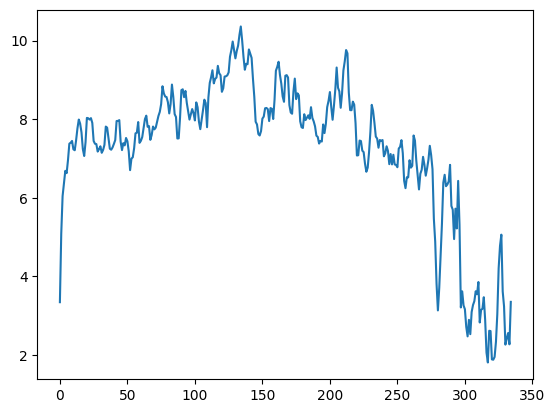

In [24]:
plt.plot(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.keys(), xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values())
plt.show()
plt.plot(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.keys(), xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values())
plt.show()
plt.plot(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.keys(), xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values())
plt.show()

In [25]:
minN__barh = [itrK for itrK, itrV in xldf__01_01__barh__train_x__y_n__metric_rmse__dct.items() if itrV == min(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values())][-1]
minN__dadri = [itrK for itrK, itrV in xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.items() if itrV == min(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values())][-1]
minN__kudgi = [itrK for itrK, itrV in xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.items() if itrV == min(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values())][-1]

maxN__barh = [itrK for itrK, itrV in xldf__01_01__barh__train_x__y_n__metric_rmse__dct.items() if itrV == max(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values())][-1]
maxN__dadri = [itrK for itrK, itrV in xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.items() if itrV == max(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values())][-1]
maxN__kudgi = [itrK for itrK, itrV in xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.items() if itrV == max(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values())][-1]


local_maxN__barh = xldf__01_01__barh__train_x__y_n__metric_rmse__dct[maxN__barh]
local_minN__barh = xldf__01_01__barh__train_x__y_n__metric_rmse__dct[min(dict(list(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.items())[:maxN__barh]), key=dict(list(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.items())[:maxN__barh]).get)]
local_avgN__barh = list({itrKV : xldf__01_01__barh__train_x__y_n__metric_rmse__dct[itrKV] for itrKV in range(maxN__barh) if xldf__01_01__barh__train_x__y_n__metric_rmse__dct[itrKV] <= ((local_minN__barh + local_maxN__barh)/2)}.keys())[-1]

local_maxN__dadri = xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[maxN__dadri]
local_minN__dadri = xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[min(dict(list(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.items())[:maxN__dadri]), key=dict(list(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.items())[:maxN__dadri]).get)]
local_avgN__dadri = list({itrKV : xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[itrKV] for itrKV in range(maxN__dadri) if xldf__01_01__dadri__train_x__y_n__metric_rmse__dct[itrKV] <= ((local_minN__dadri + local_maxN__dadri)/2)}.keys())[-1]

local_maxN__kudgi = xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[maxN__kudgi]
local_minN__kudgi = xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[min(dict(list(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.items())[:maxN__kudgi]), key=dict(list(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.items())[:maxN__kudgi]).get)]
local_avgN__kudgi = list({itrKV : xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[itrKV] for itrKV in range(maxN__kudgi) if xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct[itrKV] <= ((local_minN__kudgi + local_maxN__kudgi)/2)}.keys())[-1]

print(f"{minN__barh = } || {min(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print(f"{minN__dadri = } || {min(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print(f"{minN__kudgi = } || {min(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print()
print(f"{maxN__barh = } || {max(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print(f"{maxN__dadri = } || {max(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print(f"{maxN__kudgi = } || {max(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values()) = :.4f}")
print()
print()
print(f"{local_avgN__barh = } days")
print(f"{local_avgN__dadri = } days")
print(f"{local_avgN__kudgi = } days")

minN__barh = 192 || min(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values()) = 4.2900
minN__dadri = 250 || min(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values()) = 0.7195
minN__kudgi = 317 || min(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values()) = 1.8110

maxN__barh = 147 || max(xldf__01_01__barh__train_x__y_n__metric_rmse__dct.values()) = 12.7164
maxN__dadri = 114 || max(xldf__01_01__dadri__train_x__y_n__metric_rmse__dct.values()) = 7.9497
maxN__kudgi = 134 || max(xldf__01_01__kudgi__train_x__y_n__metric_rmse__dct.values()) = 10.3590


local_avgN__barh = 133 days
local_avgN__dadri = 105 days
local_avgN__kudgi = 52 days


---

In [26]:
xldf__01_01__barh__train_x, xldf__01_01__barh__test_x = xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][0:-201], xldf__01_01__barh__11[xldf__01_01__barh__11.columns.difference(["powerGW"], sort=False)][-201:xldf__01_01__barh__11.shape[0]-minN__barh]
xldf__01_01__barh__train_y, xldf__01_01__barh__test_y = xldf__01_01__barh__11[["powerGW"]][minN__barh:-(201-minN__barh)], xldf__01_01__barh__11[["powerGW"]][-(201-minN__barh):xldf__01_01__barh__11.shape[0]]

xldf__01_01__dadri__train_x, xldf__01_01__dadri__test_x = xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][0:-251], xldf__01_01__dadri__11[xldf__01_01__dadri__11.columns.difference(["powerGW"], sort=False)][-251:xldf__01_01__dadri__11.shape[0]-minN__dadri]
xldf__01_01__dadri__train_y, xldf__01_01__dadri__test_y = xldf__01_01__dadri__11[["powerGW"]][minN__dadri:-(251-minN__dadri)], xldf__01_01__dadri__11[["powerGW"]][-(251-minN__dadri):xldf__01_01__dadri__11.shape[0]]

xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__test_x = xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][0:-335], xldf__01_01__kudgi__11[xldf__01_01__kudgi__11.columns.difference(["powerGW"], sort=False)][-335:xldf__01_01__kudgi__11.shape[0]-minN__kudgi]
xldf__01_01__kudgi__train_y, xldf__01_01__kudgi__test_y = xldf__01_01__kudgi__11[["powerGW"]][minN__kudgi:-(335-minN__kudgi)], xldf__01_01__kudgi__11[["powerGW"]][-(335-minN__kudgi):xldf__01_01__kudgi__11.shape[0]]

In [27]:
model_barh__lightgbm = LGBMRegressor(iterations=201, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_barh__lightgbm.fit(xldf__01_01__barh__train_x, xldf__01_01__barh__train_y, eval_set=(xldf__01_01__barh__test_x, xldf__01_01__barh__test_y))
model_barh__lightgbm_predict = model_barh__lightgbm.predict(xldf__01_01__barh__test_x)

model_dadri__lightgbm = LGBMRegressor(iterations=251, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_dadri__lightgbm.fit(xldf__01_01__dadri__train_x, xldf__01_01__dadri__train_y, eval_set=(xldf__01_01__dadri__test_x, xldf__01_01__dadri__test_y))
model_dadri__lightgbm_predict = model_dadri__lightgbm.predict(xldf__01_01__dadri__test_x)

model_kudgi__lightgbm = LGBMRegressor(iterations=335, learning_rate=0.08, depth=7, loss_function="RMSE", random_seed=0, verbose=-1)
model_kudgi__lightgbm.fit(xldf__01_01__kudgi__train_x, xldf__01_01__kudgi__train_y, eval_set=(xldf__01_01__kudgi__test_x, xldf__01_01__kudgi__test_y))
model_kudgi__lightgbm_predict = model_kudgi__lightgbm.predict(xldf__01_01__kudgi__test_x)


# model_barh__lightgbm__conf96_upper = [model_barh__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__barh__test_y.values.flatten()-model_barh__lightgbm_predict))]
# model_barh__lightgbm__conf96_lower = [model_barh__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__barh__test_y.values.flatten()-model_barh__lightgbm_predict))]
# model_dadri__lightgbm__conf96_upper = [model_dadri__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__dadri__test_y.values.flatten()-model_dadri__lightgbm_predict))]
# model_dadri__lightgbm__conf96_lower = [model_dadri__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__dadri__test_y.values.flatten()-model_dadri__lightgbm_predict))]
# model_kudgi__lightgbm__conf96_upper = [model_kudgi__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__kudgi__test_y.values.flatten()-model_kudgi__lightgbm_predict))]
# model_kudgi__lightgbm__conf96_lower = [model_kudgi__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__kudgi__test_y.values.flatten()-model_kudgi__lightgbm_predict))]

In [28]:
print("LightGBM")
print()
print()
print("metrics")
print("barh RMSE:", sqrt(mean_squared_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict)))
print("barh MAPE:", mean_absolute_percentage_error(xldf__01_01__barh__test_y, model_barh__lightgbm_predict)*100)
print("dadri RMSE:", sqrt(mean_squared_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict)))
print("dadri MAPE:", mean_absolute_percentage_error(xldf__01_01__dadri__test_y, model_dadri__lightgbm_predict)*100)
print("kudgi RMSE:", sqrt(mean_squared_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict)))
print("kudgi MAPE:", mean_absolute_percentage_error(xldf__01_01__kudgi__test_y, model_kudgi__lightgbm_predict)*100)
print()
# print("plot")
# plt.plot(xldf__01_01__barh__test_x.index, model_barh__lightgbm_predict)
# plt.plot(xldf__01_01__barh__test_x.index, xldf__01_01__barh__test_y)
# plt.show()
# plt.plot(xldf__01_01__dadri__test_x.index, model_dadri__lightgbm_predict)
# plt.plot(xldf__01_01__dadri__test_x.index, xldf__01_01__dadri__test_y)
# plt.show()
# plt.plot(xldf__01_01__kudgi__test_x.index, model_kudgi__lightgbm_predict)
# plt.plot(xldf__01_01__kudgi__test_x.index, xldf__01_01__kudgi__test_y)
# plt.show()

LightGBM


metrics
barh RMSE: 4.290011757503457
barh MAPE: 8.5059935366304
dadri RMSE: 0.7194978015112525
dadri MAPE: 2.3566911284351537
kudgi RMSE: 1.8109533812114624
kudgi MAPE: 3.5450454890723395



In [29]:
model_barh__lightgbm_predict = model_barh__lightgbm.predict(xldf__01_01__barh__x)
model_dadri__lightgbm_predict = model_dadri__lightgbm.predict(xldf__01_01__dadri__x)
model_kudgi__lightgbm_predict = model_kudgi__lightgbm.predict(xldf__01_01__kudgi__x)


model_barh__lightgbm_predict__conf96_upper = [model_barh__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__barh__y.values.flatten()-model_barh__lightgbm_predict))]
model_barh__lightgbm_predict__conf96_lower = [model_barh__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__barh__y.values.flatten()-model_barh__lightgbm_predict))]
model_dadri__lightgbm_predict__conf96_upper = [model_dadri__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__dadri__y.values.flatten()-model_dadri__lightgbm_predict))]
model_dadri__lightgbm_predict__conf96_lower = [model_dadri__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__dadri__y.values.flatten()-model_dadri__lightgbm_predict))]
model_kudgi__lightgbm_predict__conf96_upper = [model_kudgi__lightgbm_predict + (np.array([2.06])*np.std(xldf__01_01__kudgi__y.values.flatten()-model_kudgi__lightgbm_predict))]
model_kudgi__lightgbm_predict__conf96_lower = [model_kudgi__lightgbm_predict - (np.array([2.06])*np.std(xldf__01_01__kudgi__y.values.flatten()-model_kudgi__lightgbm_predict))]

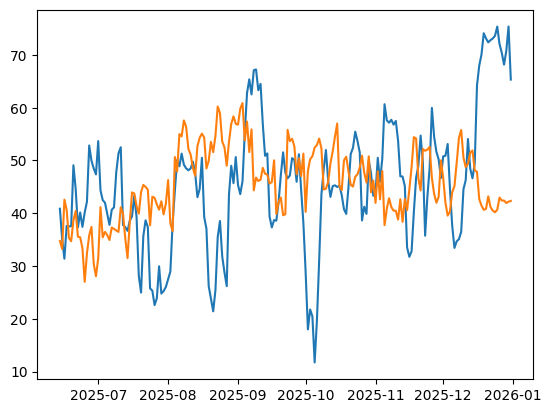

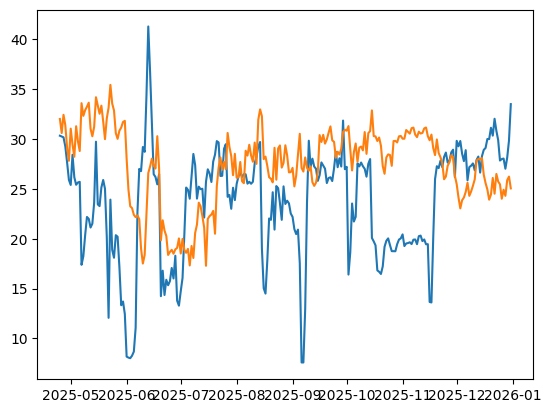

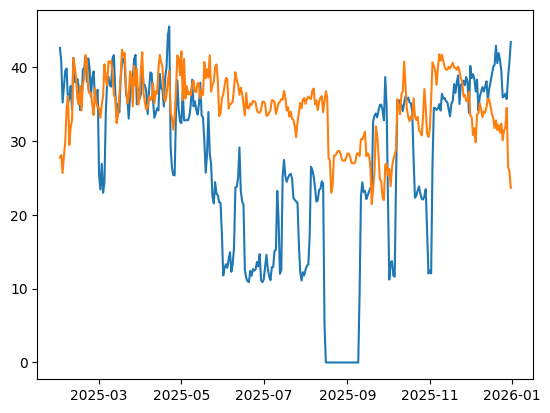

In [30]:
plt.plot(xldf__01_01__barh__x.index, xldf__01_01__barh__y)
plt.plot(xldf__01_01__barh__x.index, model_barh__lightgbm_predict)
plt.show()
plt.plot(xldf__01_01__dadri__x.index, xldf__01_01__dadri__y)
plt.plot(xldf__01_01__dadri__x.index, model_dadri__lightgbm_predict)
plt.show()
plt.plot(xldf__01_01__kudgi__x.index, xldf__01_01__kudgi__y)
plt.plot(xldf__01_01__kudgi__x.index, model_kudgi__lightgbm_predict)
plt.show()

---

In [31]:
xldf__01_01__barh__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__barh__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__barh__00.index[-1] + pd.Timedelta(days=maxN__barh)), columns=xldf__01_01__barh__00.columns)
xldf__01_01__barh__forecast_io = pd.concat\
                                    ([
                                        xldf__01_01__barh[xldf__01_01__barh.shape[0]-7 : xldf__01_01__barh.shape[0]].round(4),
                                        xldf__01_01__barh__forecast
                                    ])
xldf__01_01__barh__forecast_io.fillna(-1, inplace=True)

for itr in range(0, maxN__barh):
    for jtr in range(0, 7): xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7:itr+(7*2)], f"lg{jtr+1}"] = xldf__01_01__barh__forecast_io["powerGW"].shift(jtr+1)
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'lgmn7'] = \
        xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7]].iloc[0:7].mean().round(4)
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'lgvr7'] = \
        xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7]].iloc[0:7].var().round(4)
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'lgsd7'] = \
        xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7]].iloc[0:7].std().round(4)
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'nyweek'] = \
        xldf__01_01__barh__forecast_io.index[itr+7].isocalendar().week
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'nmweek'] = \
        xldf__01_01__barh__forecast_io.index[itr+7].month
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'ndweek'] = \
        xldf__01_01__barh__forecast_io.index[itr+7].dayofweek
    
    model_barh__lightgbm_predict__forecast = \
        model_barh__lightgbm.predict\
            (
                xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7]].iloc[0:-1].to_frame().T.astype(xldf__01_01__barh__00[xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[7]].iloc[0:-1].to_frame().T.columns].dtypes.to_dict())
            )
    xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7], 'powerGW'] = \
        model_barh__lightgbm_predict__forecast.astype(xldf__01_01__barh__00[xldf__01_01__barh__forecast_io.columns[-1]].dtypes).round(2)
    
    xldf__01_01__barh__forecast.loc[xldf__01_01__barh__forecast.index[itr]] = xldf__01_01__barh__forecast_io.loc[xldf__01_01__barh__forecast_io.index[itr+7]]

plt.plot(xldf__01_01__barh__forecast.index, xldf__01_01__barh__forecast["powerGW"])

C:\Users\Aditya.Kothapalli\AppData\Local\Temp\ipykernel_34424\3047494649.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  xldf__01_01__barh__forecast_io = pd.concat\


OverflowError: Python integer -1 out of bounds for uint32

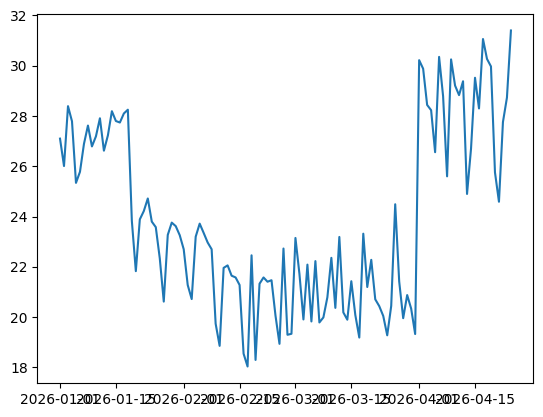

In [ ]:
xldf__01_01__dadri__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__dadri__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__dadri__00.index[-1] + pd.Timedelta(days=maxN__dadri)), columns=xldf__01_01__dadri__00.columns)
xldf__01_01__dadri__forecast_io = pd.concat\
                                    ([
                                        xldf__01_01__dadri[xldf__01_01__dadri.shape[0]-7 : xldf__01_01__dadri.shape[0]].round(4),
                                        xldf__01_01__dadri__forecast
                                    ])
xldf__01_01__dadri__forecast_io.fillna(-1, inplace=True)

for itr in range(0, maxN__dadri):
    for jtr in range(0, 7): xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7:itr+(7*2)], f"lg{jtr+1}"] = xldf__01_01__dadri__forecast_io["powerGW"].shift(jtr+1)
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'lgmn7'] = \
        xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7]].iloc[0:7].mean().round(4)
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'lgvr7'] = \
        xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7]].iloc[0:7].var().round(4)
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'lgsd7'] = \
        xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7]].iloc[0:7].std().round(4)
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'nyweek'] = \
        xldf__01_01__dadri__forecast_io.index[itr+7].isocalendar().week
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'nmweek'] = \
        xldf__01_01__dadri__forecast_io.index[itr+7].month
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'ndweek'] = \
        xldf__01_01__dadri__forecast_io.index[itr+7].dayofweek
    
    model_dadri__lightgbm_predict__forecast = \
        model_dadri__lightgbm.predict\
            (
                xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7]].iloc[0:-1].to_frame().T.astype(xldf__01_01__dadri__00[xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[7]].iloc[0:-1].to_frame().T.columns].dtypes.to_dict())
            )
    xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7], 'powerGW'] = \
        model_dadri__lightgbm_predict__forecast.astype(xldf__01_01__dadri__00[xldf__01_01__dadri__forecast_io.columns[-1]].dtypes).round(2)
    
    xldf__01_01__dadri__forecast.loc[xldf__01_01__dadri__forecast.index[itr]] = xldf__01_01__dadri__forecast_io.loc[xldf__01_01__dadri__forecast_io.index[itr+7]]

plt.plot(xldf__01_01__dadri__forecast.index, xldf__01_01__dadri__forecast["powerGW"])

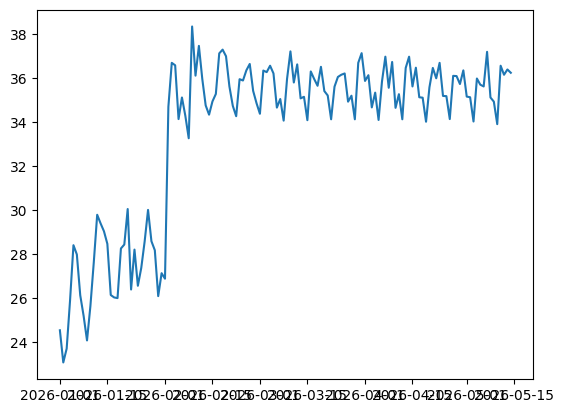

In [ ]:
xldf__01_01__kudgi__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__kudgi__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__kudgi__00.index[-1] + pd.Timedelta(days=maxN__kudgi)), columns=xldf__01_01__kudgi__00.columns)
xldf__01_01__kudgi__forecast_io = pd.concat\
                                    ([
                                        xldf__01_01__kudgi[xldf__01_01__kudgi.shape[0]-7 : xldf__01_01__kudgi.shape[0]].round(4),
                                        xldf__01_01__kudgi__forecast
                                    ])
xldf__01_01__kudgi__forecast_io.fillna(-1, inplace=True)

for itr in range(0, maxN__kudgi):
    for jtr in range(0, 7): xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7:itr+(7*2)], f"lg{jtr+1}"] = xldf__01_01__kudgi__forecast_io["powerGW"].shift(jtr+1)
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'lgmn7'] = \
        xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7]].iloc[0:7].mean().round(4)
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'lgvr7'] = \
        xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7]].iloc[0:7].var().round(4)
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'lgsd7'] = \
        xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7]].iloc[0:7].std().round(4)
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'nyweek'] = \
        xldf__01_01__kudgi__forecast_io.index[itr+7].isocalendar().week
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'nmweek'] = \
        xldf__01_01__kudgi__forecast_io.index[itr+7].month
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'ndweek'] = \
        xldf__01_01__kudgi__forecast_io.index[itr+7].dayofweek
    
    model_kudgi__lightgbm_predict__forecast = \
        model_kudgi__lightgbm.predict\
            (
                xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7]].iloc[0:-1].to_frame().T.astype(xldf__01_01__kudgi__00[xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[7]].iloc[0:-1].to_frame().T.columns].dtypes.to_dict())
            )
    xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7], 'powerGW'] = \
        model_kudgi__lightgbm_predict__forecast.astype(xldf__01_01__kudgi__00[xldf__01_01__kudgi__forecast_io.columns[-1]].dtypes).round(2)
    
    xldf__01_01__kudgi__forecast.loc[xldf__01_01__kudgi__forecast.index[itr]] = xldf__01_01__kudgi__forecast_io.loc[xldf__01_01__kudgi__forecast_io.index[itr+7]]

plt.plot(xldf__01_01__kudgi__forecast.index, xldf__01_01__kudgi__forecast["powerGW"])

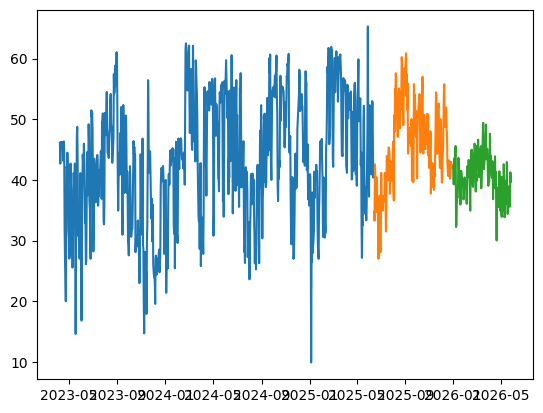

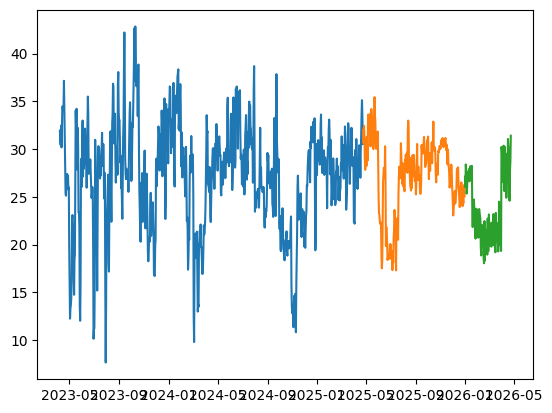

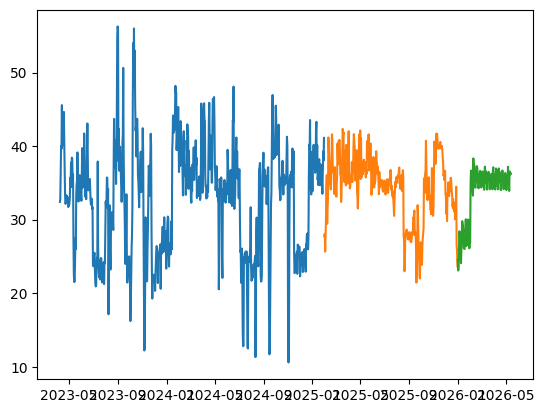

In [ ]:
plt.plot(xldf__01_01__barh__11.index, xldf__01_01__barh__11["powerGW"])
plt.plot(xldf__01_01__barh__x.index, model_barh__lightgbm_predict)
plt.plot(xldf__01_01__barh__forecast.index, xldf__01_01__barh__forecast["powerGW"])
plt.show()
plt.plot(xldf__01_01__dadri__11.index, xldf__01_01__dadri__11["powerGW"])
plt.plot(xldf__01_01__dadri__x.index, model_dadri__lightgbm_predict)
plt.plot(xldf__01_01__dadri__forecast.index, xldf__01_01__dadri__forecast["powerGW"])
plt.show()
plt.plot(xldf__01_01__kudgi__11.index, xldf__01_01__kudgi__11["powerGW"])
plt.plot(xldf__01_01__kudgi__x.index, model_kudgi__lightgbm_predict)
plt.plot(xldf__01_01__kudgi__forecast.index, xldf__01_01__kudgi__forecast["powerGW"])
plt.show()

---

In [ ]:
xldf__01_01__barh__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__barh__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__barh__00.index[-1] + pd.Timedelta(days=maxN__barh)), columns=["powerGW"])
xldf__01_01__barh__forecast["powerGW"] = model_barh__lightgbm.predict(xldf__01_01__barh__00.iloc[xldf__01_01__barh__00.shape[0]-maxN__barh:xldf__01_01__barh__00.shape[0], 0:-1])

xldf__01_01__dadri__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__dadri__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__dadri__00.index[-1] + pd.Timedelta(days=maxN__dadri)), columns=["powerGW"])
xldf__01_01__dadri__forecast["powerGW"] = model_dadri__lightgbm.predict(xldf__01_01__dadri__00.iloc[xldf__01_01__dadri__00.shape[0]-maxN__dadri:xldf__01_01__dadri__00.shape[0], 0:-1])

xldf__01_01__kudgi__forecast = pd.DataFrame(index=pd.date_range(xldf__01_01__kudgi__00.index[-1] + pd.Timedelta(days=1), xldf__01_01__kudgi__00.index[-1] + pd.Timedelta(days=maxN__kudgi)), columns=["powerGW"])
xldf__01_01__kudgi__forecast["powerGW"] = model_kudgi__lightgbm.predict(xldf__01_01__kudgi__00.iloc[xldf__01_01__kudgi__00.shape[0]-maxN__kudgi:xldf__01_01__kudgi__00.shape[0], 0:-1])


model_barh__lightgbm_predict__conf96_upper = [xldf__01_01__barh__forecast["powerGW"].values + (np.array([2.06])*np.std(xldf__01_01__barh__y.values.flatten()-model_barh__lightgbm_predict))]
model_barh__lightgbm_predict__conf96_lower = [xldf__01_01__barh__forecast["powerGW"].values - (np.array([2.06])*np.std(xldf__01_01__barh__y.values.flatten()-model_barh__lightgbm_predict))]
model_dadri__lightgbm_predict__conf96_upper = [xldf__01_01__dadri__forecast["powerGW"].values + (np.array([2.06])*np.std(xldf__01_01__dadri__y.values.flatten()-model_dadri__lightgbm_predict))]
model_dadri__lightgbm_predict__conf96_lower = [xldf__01_01__dadri__forecast["powerGW"].values - (np.array([2.06])*np.std(xldf__01_01__dadri__y.values.flatten()-model_dadri__lightgbm_predict))]
model_kudgi__lightgbm_predict__conf96_upper = [xldf__01_01__kudgi__forecast["powerGW"].values + (np.array([2.06])*np.std(xldf__01_01__kudgi__y.values.flatten()-model_kudgi__lightgbm_predict))]
model_kudgi__lightgbm_predict__conf96_lower = [xldf__01_01__kudgi__forecast["powerGW"].values - (np.array([2.06])*np.std(xldf__01_01__kudgi__y.values.flatten()-model_kudgi__lightgbm_predict))]

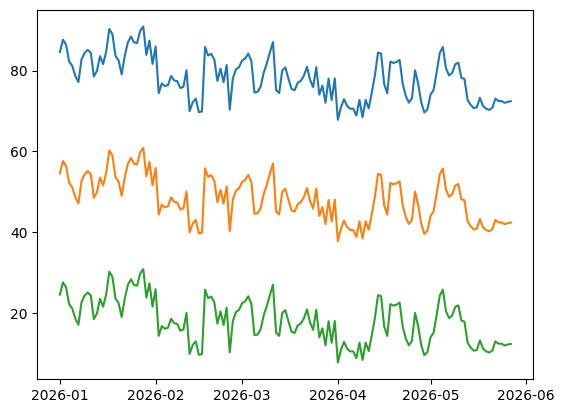

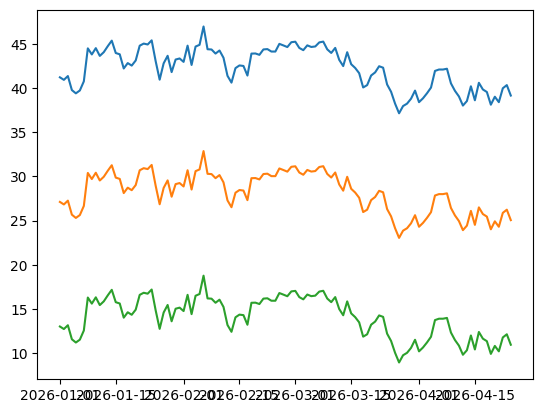

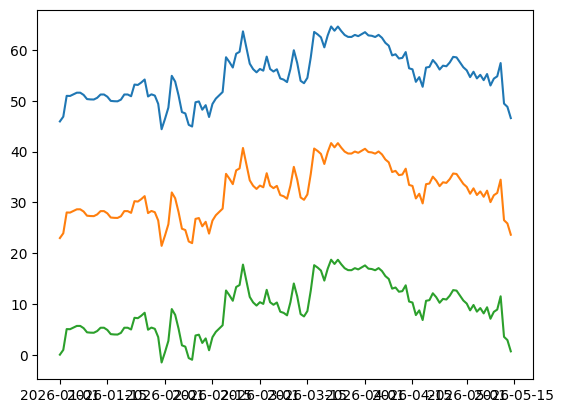

In [ ]:
plt.plot(xldf__01_01__barh__forecast.index, pd.Series(model_barh__lightgbm_predict__conf96_upper).values[0])
plt.plot(xldf__01_01__barh__forecast.index, xldf__01_01__barh__forecast["powerGW"])
plt.plot(xldf__01_01__barh__forecast.index, pd.Series(model_barh__lightgbm_predict__conf96_lower).values[0])
plt.show()
plt.plot(xldf__01_01__dadri__forecast.index, pd.Series(model_dadri__lightgbm_predict__conf96_upper).values[0])
plt.plot(xldf__01_01__dadri__forecast.index, xldf__01_01__dadri__forecast["powerGW"])
plt.plot(xldf__01_01__dadri__forecast.index, pd.Series(model_dadri__lightgbm_predict__conf96_lower).values[0])
plt.show()
plt.plot(xldf__01_01__kudgi__forecast.index, pd.Series(model_kudgi__lightgbm_predict__conf96_upper).values[0])
plt.plot(xldf__01_01__kudgi__forecast.index, xldf__01_01__kudgi__forecast["powerGW"])
plt.plot(xldf__01_01__kudgi__forecast.index, pd.Series(model_kudgi__lightgbm_predict__conf96_lower).values[0])
plt.show()

---

In [ ]:
model_barh__lightgbm_predict__zs98_upper = xldf__01_01__barh__forecast[xldf__01_01__barh__forecast["powerGW"] >= xldf__01_01__barh__forecast["powerGW"].quantile(0.98)]["powerGW"]
model_barh__lightgbm_predict__zs02_lower = xldf__01_01__barh__forecast[xldf__01_01__barh__forecast["powerGW"] <= xldf__01_01__barh__forecast["powerGW"].quantile(0.02)]["powerGW"]
model_dadri__lightgbm_predict__zs98_upper = xldf__01_01__dadri__forecast[xldf__01_01__dadri__forecast["powerGW"] >= xldf__01_01__dadri__forecast["powerGW"].quantile(0.98)]["powerGW"]
model_dadri__lightgbm_predict__zs02_lower = xldf__01_01__dadri__forecast[xldf__01_01__dadri__forecast["powerGW"] <= xldf__01_01__dadri__forecast["powerGW"].quantile(0.02)]["powerGW"]
model_kudgi__lightgbm_predict__zs98_upper = xldf__01_01__kudgi__forecast[xldf__01_01__kudgi__forecast["powerGW"] >= xldf__01_01__kudgi__forecast["powerGW"].quantile(0.98)]["powerGW"]
model_kudgi__lightgbm_predict__zs02_lower = xldf__01_01__kudgi__forecast[xldf__01_01__kudgi__forecast["powerGW"] <= xldf__01_01__kudgi__forecast["powerGW"].quantile(0.02)]["powerGW"]

In [ ]:
df__model_barh__lightgbm_predict__upper_zs98conf96 = pd.Series(model_barh__lightgbm_predict__conf96_upper[0], name="conf96__upper", index=xldf__01_01__barh__forecast.index)
df__model_barh__lightgbm_predict__upper_zs98conf96 = df__model_barh__lightgbm_predict__upper_zs98conf96.loc[model_barh__lightgbm_predict__zs98_upper.index]
df__model_barh__lightgbm_predict__lower_zs02conf96 = pd.Series(model_barh__lightgbm_predict__conf96_lower[0], name="conf96__lower", index=xldf__01_01__barh__forecast.index)
df__model_barh__lightgbm_predict__lower_zs02conf96 = df__model_barh__lightgbm_predict__lower_zs02conf96.loc[model_barh__lightgbm_predict__zs02_lower.index]

df__model_dadri__lightgbm_predict__upper_zs98conf96 = pd.Series(model_dadri__lightgbm_predict__conf96_upper[0], name="conf96__upper", index=xldf__01_01__dadri__forecast.index)
df__model_dadri__lightgbm_predict__upper_zs98conf96 = df__model_dadri__lightgbm_predict__upper_zs98conf96.loc[model_dadri__lightgbm_predict__zs98_upper.index]
df__model_dadri__lightgbm_predict__lower_zs02conf96 = pd.Series(model_dadri__lightgbm_predict__conf96_lower[0], name="conf96__lower", index=xldf__01_01__dadri__forecast.index)
df__model_dadri__lightgbm_predict__lower_zs02conf96 = df__model_dadri__lightgbm_predict__lower_zs02conf96.loc[model_dadri__lightgbm_predict__zs02_lower.index]

df__model_kudgi__lightgbm_predict__upper_zs98conf96 = pd.Series(model_kudgi__lightgbm_predict__conf96_upper[0], name="conf96__upper", index=xldf__01_01__kudgi__forecast.index)
df__model_kudgi__lightgbm_predict__upper_zs98conf96 = df__model_kudgi__lightgbm_predict__upper_zs98conf96.loc[model_kudgi__lightgbm_predict__zs98_upper.index]
df__model_kudgi__lightgbm_predict__lower_zs02conf96 = pd.Series(model_kudgi__lightgbm_predict__conf96_lower[0], name="conf96__lower", index=xldf__01_01__kudgi__forecast.index)
df__model_kudgi__lightgbm_predict__lower_zs02conf96 = df__model_kudgi__lightgbm_predict__lower_zs02conf96.loc[model_kudgi__lightgbm_predict__zs02_lower.index]

In [ ]:
display(df__model_barh__lightgbm_predict__upper_zs98conf96.to_frame())
display(df__model_dadri__lightgbm_predict__upper_zs98conf96.to_frame())
display(df__model_kudgi__lightgbm_predict__upper_zs98conf96.to_frame())

,conf96__upper
2026-01-17,90.306217
2026-01-27,89.881634
2026-01-28,90.948586


,conf96__upper
2026-01-14,45.385316
2026-01-24,45.418684
2026-02-06,46.989231


,conf96__upper
2026-03-22,64.659018
2026-03-23,63.821753
2026-03-24,64.651687


In [ ]:
display(df__model_barh__lightgbm_predict__lower_zs02conf96.to_frame())
display(df__model_dadri__lightgbm_predict__lower_zs02conf96.to_frame())
display(df__model_kudgi__lightgbm_predict__lower_zs02conf96.to_frame())

,conf96__lower
2026-04-01,7.666015
2026-04-07,8.720588
2026-04-09,8.293979


,conf96__lower
2026-03-27,8.937923
2026-03-28,9.757553
2026-04-12,9.812900


,conf96__lower
2026-01-31,-1.530639
2026-02-08,-0.664732
2026-02-09,-0.993981


---

In [ ]:
plt__model_barh__lightgbm = go.Figure()
plt__model_barh__lightgbm.add_trace(go.Scatter(x=xldf__01_01__barh.index, y=xldf__01_01__barh["powerGW"], mode='lines', name=f"past", line=dict(color='gray')))
plt__model_barh__lightgbm.add_trace(go.Scatter(x=pd.DatetimeIndex([xldf__01_01__barh.index.values[-1]] + [pd.Timestamp(itr) for itr in xldf__01_01__barh__forecast.index.values.tolist()]), y=np.array([xldf__01_01__barh["powerGW"].iloc[-1]] + xldf__01_01__barh__forecast["powerGW"].tolist()).astype(float), mode='lines', line=dict(color='black'), name=f"future"))
plt__model_barh__lightgbm.add_trace(go.Scatter(x=list(xldf__01_01__barh__forecast.index[0::]) + list(xldf__01_01__barh__forecast.index[::-1]), y=list(model_barh__lightgbm_predict__conf96_upper[0].ravel()[0::])+list(model_barh__lightgbm_predict__conf96_lower[0].ravel()[::-1]), fill='toself', fillcolor='rgba(0,128,0,0.2)', line=dict(color='rgba(0,0,0,0)'), hoverinfo='skip', name="future :: conf96 upper interval"))
plt__model_barh__lightgbm.add_trace(go.Scatter(x=df__model_barh__lightgbm_predict__upper_zs98conf96.index, y=df__model_barh__lightgbm_predict__upper_zs98conf96.values, mode='markers', marker=dict(color='red'), name=f"future :: zs98conf96 upper interval"))
plt__model_barh__lightgbm.add_trace(go.Scatter(x=df__model_barh__lightgbm_predict__lower_zs02conf96.index, y=df__model_barh__lightgbm_predict__lower_zs02conf96.values, mode='markers', marker=dict(color='blue'), name=f"future :: zs02conf96 lower interval"))
plt__model_barh__lightgbm.show()


plt__model_dadri__lightgbm = go.Figure()
plt__model_dadri__lightgbm.add_trace(go.Scatter(x=xldf__01_01__dadri.index, y=xldf__01_01__dadri["powerGW"], mode='lines', name=f"past", line=dict(color='gray')))
plt__model_dadri__lightgbm.add_trace(go.Scatter(x=pd.DatetimeIndex([xldf__01_01__dadri.index.values[-1]] + [pd.Timestamp(itr) for itr in xldf__01_01__dadri__forecast.index.values.tolist()]), y=np.array([xldf__01_01__dadri["powerGW"].iloc[-1]] + xldf__01_01__dadri__forecast["powerGW"].tolist()).astype(float), mode='lines', line=dict(color='black'), name=f"future"))
plt__model_dadri__lightgbm.add_trace(go.Scatter(x=list(xldf__01_01__dadri__forecast.index[0::]) + list(xldf__01_01__dadri__forecast.index[::-1]), y=list(model_dadri__lightgbm_predict__conf96_upper[0].ravel()[0::])+list(model_dadri__lightgbm_predict__conf96_lower[0].ravel()[::-1]), fill='toself', fillcolor='rgba(0,128,0,0.2)', line=dict(color='rgba(0,0,0,0)'), hoverinfo='skip', name="future :: conf96 upper interval"))
plt__model_dadri__lightgbm.add_trace(go.Scatter(x=df__model_dadri__lightgbm_predict__upper_zs98conf96.index, y=df__model_dadri__lightgbm_predict__upper_zs98conf96.values, mode='markers', marker=dict(color='red'), name=f"future :: zs98conf96 upper interval"))
plt__model_dadri__lightgbm.add_trace(go.Scatter(x=df__model_dadri__lightgbm_predict__lower_zs02conf96.index, y=df__model_dadri__lightgbm_predict__lower_zs02conf96.values, mode='markers', marker=dict(color='blue'), name=f"future :: zs02conf96 lower interval"))
plt__model_dadri__lightgbm.show()


plt__model_kudgi__lightgbm = go.Figure()
plt__model_kudgi__lightgbm.add_trace(go.Scatter(x=xldf__01_01__kudgi.index, y=xldf__01_01__kudgi["powerGW"], mode='lines', name=f"past", line=dict(color='gray')))
plt__model_kudgi__lightgbm.add_trace(go.Scatter(x=pd.DatetimeIndex([xldf__01_01__kudgi.index.values[-1]] + [pd.Timestamp(itr) for itr in xldf__01_01__kudgi__forecast.index.values.tolist()]), y=np.array([xldf__01_01__kudgi["powerGW"].iloc[-1]] + xldf__01_01__kudgi__forecast["powerGW"].tolist()).astype(float), mode='lines', line=dict(color='black'), name=f"future"))
plt__model_kudgi__lightgbm.add_trace(go.Scatter(x=list(xldf__01_01__kudgi__forecast.index[0::]) + list(xldf__01_01__kudgi__forecast.index[::-1]), y=list(model_kudgi__lightgbm_predict__conf96_upper[0].ravel()[0::])+list(model_kudgi__lightgbm_predict__conf96_lower[0].ravel()[::-1]), fill='toself', fillcolor='rgba(0,128,0,0.2)', line=dict(color='rgba(0,0,0,0)'), hoverinfo='skip', name="future :: conf96 upper interval"))
plt__model_kudgi__lightgbm.add_trace(go.Scatter(x=df__model_kudgi__lightgbm_predict__upper_zs98conf96.index, y=df__model_kudgi__lightgbm_predict__upper_zs98conf96.values, mode='markers', marker=dict(color='red'), name=f"future :: zs98conf96 upper interval"))
plt__model_kudgi__lightgbm.add_trace(go.Scatter(x=df__model_kudgi__lightgbm_predict__lower_zs02conf96.index, y=df__model_kudgi__lightgbm_predict__lower_zs02conf96.values, mode='markers', marker=dict(color='blue'), name=f"future :: zs02conf96 lower interval"))
plt__model_kudgi__lightgbm.show()

In [ ]:
df__model_barh__lightgbm_predict__zs98conf96__upper = pd.DataFrame(columns=["powerGW", "conf96__upper", f"futureNdays__{xldf__01_01__barh.index[-1].strftime("%Y%m%d")}"], index=model_barh__lightgbm_predict__zs98_upper.index)
df__model_barh__lightgbm_predict__zs98conf96__upper["powerGW"] = model_barh__lightgbm_predict__zs98_upper.values
df__model_barh__lightgbm_predict__zs98conf96__upper["conf96__upper"] = df__model_barh__lightgbm_predict__upper_zs98conf96.values
df__model_barh__lightgbm_predict__zs98conf96__upper[f"futureNdays__{xldf__01_01__barh.index[-1].strftime("%Y%m%d")}"] = (df__model_barh__lightgbm_predict__zs98conf96__upper.index - xldf__01_01__barh.index[-1]).days

df__model_dadri__lightgbm_predict__zs98conf96__upper = pd.DataFrame(columns=["powerGW", "conf96__upper", f"futureNdays__{xldf__01_01__dadri.index[-1].strftime("%Y%m%d")}"], index=model_dadri__lightgbm_predict__zs98_upper.index)
df__model_dadri__lightgbm_predict__zs98conf96__upper["powerGW"] = model_dadri__lightgbm_predict__zs98_upper.values
df__model_dadri__lightgbm_predict__zs98conf96__upper["conf96__upper"] = df__model_dadri__lightgbm_predict__upper_zs98conf96.values
df__model_dadri__lightgbm_predict__zs98conf96__upper[f"futureNdays__{xldf__01_01__dadri.index[-1].strftime("%Y%m%d")}"] = (df__model_dadri__lightgbm_predict__zs98conf96__upper.index - xldf__01_01__dadri.index[-1]).days

df__model_kudgi__lightgbm_predict__zs98conf96__upper = pd.DataFrame(columns=["powerGW", "conf96__upper", f"futureNdays__{xldf__01_01__kudgi.index[-1].strftime("%Y%m%d")}"], index=model_kudgi__lightgbm_predict__zs98_upper.index)
df__model_kudgi__lightgbm_predict__zs98conf96__upper["powerGW"] = model_kudgi__lightgbm_predict__zs98_upper.values
df__model_kudgi__lightgbm_predict__zs98conf96__upper["conf96__upper"] = df__model_kudgi__lightgbm_predict__upper_zs98conf96.values
df__model_kudgi__lightgbm_predict__zs98conf96__upper[f"futureNdays__{xldf__01_01__kudgi.index[-1].strftime("%Y%m%d")}"] = (df__model_kudgi__lightgbm_predict__zs98conf96__upper.index - xldf__01_01__kudgi.index[-1]).days


df__model_barh__lightgbm_predict__zs02conf96__lower = pd.DataFrame(columns=["conf96__lower", "powerGW", f"futureNdays__{xldf__01_01__barh.index[-1].strftime("%Y%m%d")}"], index=model_barh__lightgbm_predict__zs02_lower.index)
df__model_barh__lightgbm_predict__zs02conf96__lower["conf96__lower"] = df__model_barh__lightgbm_predict__lower_zs02conf96.values
df__model_barh__lightgbm_predict__zs02conf96__lower["powerGW"] = model_barh__lightgbm_predict__zs02_lower.values
df__model_barh__lightgbm_predict__zs02conf96__lower[f"futureNdays__{xldf__01_01__barh.index[-1].strftime("%Y%m%d")}"] = (df__model_barh__lightgbm_predict__zs02conf96__lower.index - xldf__01_01__barh.index[-1]).days

df__model_dadri__lightgbm_predict__zs02conf96__lower = pd.DataFrame(columns=["conf96__lower", "powerGW", f"futureNdays__{xldf__01_01__dadri.index[-1].strftime("%Y%m%d")}"], index=model_dadri__lightgbm_predict__zs02_lower.index)
df__model_dadri__lightgbm_predict__zs02conf96__lower["conf96__lower"] = df__model_dadri__lightgbm_predict__lower_zs02conf96.values
df__model_dadri__lightgbm_predict__zs02conf96__lower["powerGW"] = model_dadri__lightgbm_predict__zs02_lower.values
df__model_dadri__lightgbm_predict__zs02conf96__lower[f"futureNdays__{xldf__01_01__dadri.index[-1].strftime("%Y%m%d")}"] = (df__model_dadri__lightgbm_predict__zs02conf96__lower.index - xldf__01_01__dadri.index[-1]).days

df__model_kudgi__lightgbm_predict__zs02conf96__lower = pd.DataFrame(columns=["conf96__lower", "powerGW", f"futureNdays__{xldf__01_01__kudgi.index[-1].strftime("%Y%m%d")}"], index=model_kudgi__lightgbm_predict__zs02_lower.index)
df__model_kudgi__lightgbm_predict__zs02conf96__lower["conf96__lower"] = df__model_kudgi__lightgbm_predict__lower_zs02conf96.values
df__model_kudgi__lightgbm_predict__zs02conf96__lower["powerGW"] = model_kudgi__lightgbm_predict__zs02_lower.values
df__model_kudgi__lightgbm_predict__zs02conf96__lower[f"futureNdays__{xldf__01_01__kudgi.index[-1].strftime("%Y%m%d")}"] = (df__model_kudgi__lightgbm_predict__zs02conf96__lower.index - xldf__01_01__kudgi.index[-1]).days

In [ ]:
display(df__model_barh__lightgbm_predict__zs98conf96__upper)
display(df__model_dadri__lightgbm_predict__zs98conf96__upper)
display(df__model_kudgi__lightgbm_predict__zs98conf96__upper)

,powerGW,conf96__upper,futureNdays__20251231
2026-01-17,60.230161,90.306217,17
2026-01-27,59.805577,89.881634,27
2026-01-28,60.872530,90.948586,28


,powerGW,conf96__upper,futureNdays__20251231
2026-01-14,31.275534,45.385316,14
2026-01-24,31.308902,45.418684,24
2026-02-06,32.879449,46.989231,37


,powerGW,conf96__upper,futureNdays__20251231
2026-03-22,41.685611,64.659018,81
2026-03-23,40.848347,63.821753,82
2026-03-24,41.678281,64.651687,83


In [ ]:
display(df__model_barh__lightgbm_predict__zs02conf96__lower)
display(df__model_dadri__lightgbm_predict__zs02conf96__lower)
display(df__model_kudgi__lightgbm_predict__zs02conf96__lower)

,conf96__lower,powerGW,futureNdays__20251231
2026-04-01,7.666015,37.742071,91
2026-04-07,8.720588,38.796645,97
2026-04-09,8.293979,38.370035,99


,conf96__lower,powerGW,futureNdays__20251231
2026-03-27,8.937923,23.047704,86
2026-03-28,9.757553,23.867335,87
2026-04-12,9.812900,23.922681,102


,conf96__lower,powerGW,futureNdays__20251231
2026-01-31,-1.530639,21.442767,31
2026-02-08,-0.664732,22.308674,39
2026-02-09,-0.993981,21.979426,40


---

In [ ]:
with open("model/Barh/xgboost_Barh.pkl", "wb") as file__model_barh__xgboost:
    pkl.dump(model_barh__xgboost, file__model_barh__xgboost)
with open("model/Dadri/xgboost_Dadri.pkl", "wb") as file__model_dadri__xgboost:
    pkl.dump(model_barh__xgboost, file__model_dadri__xgboost)
with open("model/Kudgi/xgboost_Kudgi.pkl", "wb") as file__model_kudgi__xgboost:
    pkl.dump(model_kudgi__xgboost, file__model_kudgi__xgboost)

with open("model/Barh/lightgbm_Barh.pkl", "wb") as file__model_barh__lightgbm:
    pkl.dump(model_barh__lightgbm, file__model_barh__lightgbm)
with open("model/Dadri/lightgbm_Dadri.pkl", "wb") as file__model_dadri__lightgbm:
    pkl.dump(model_barh__lightgbm, file__model_dadri__lightgbm)
with open("model/Kudgi/lightgbm_Kudgi.pkl", "wb") as file__model_kudgi__lightgbm:
    pkl.dump(model_kudgi__lightgbm, file__model_kudgi__lightgbm)

with open("model/Barh/catboost_Barh.pkl", "wb") as file__model_barh__catboost:
    pkl.dump(model_barh__catboost, file__model_barh__catboost)
with open("model/Dadri/catboost_Dadri.pkl", "wb") as file__model_dadri__catboost:
    pkl.dump(model_barh__catboost, file__model_dadri__catboost)
with open("model/Kudgi/catboost_Kudgi.pkl", "wb") as file__model_kudgi__catboost:
    pkl.dump(model_kudgi__catboost, file__model_kudgi__catboost)

---
---